# RAG Evaluation Logs Analysis

This notebook provides comprehensive analysis of RAG evaluation logs, comparing different models, top-k values, and golden standard datasets.

## Analysis Overview
- Load and explore evaluation log files
- Compare multiple models and configurations
- Analyze performance metrics (semantic similarity, BLEU, TF-IDF)
- Handle different golden sample datasets
- Generate visualizations and insights

## 1. Import Required Libraries

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Any
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Evaluation Logs

Load all evaluation log files from the logs directory and extract key metrics.

In [2]:
def extract_config_from_filename(filename: str) -> Dict[str, Any]:
    """Extract configuration details from filename."""
    pattern = r'answer_evaluation_results_topk(\d+)_(.+?)(?:_(\d{8}_\d{6}))?\.json'
    match = re.match(pattern, filename)
    
    if match:
        top_k = int(match.group(1))
        model = match.group(2)
        timestamp = match.group(3) if match.group(3) else "unknown"
        return {"top_k": top_k, "model": model, "timestamp": timestamp}
    return {"top_k": None, "model": filename, "timestamp": "unknown"}

def load_evaluation_logs(logs_directory: str) -> pd.DataFrame:
    """Load all evaluation log files and extract key information."""
    logs_dir = Path(logs_directory)
    log_files = list(logs_dir.glob("answer_evaluation_results_*.json"))
    
    print(f"Found {len(log_files)} log files")
    
    data = []
    for log_file in log_files:
        try:
            with open(log_file, 'r', encoding='utf-8') as f:
                log_data = json.load(f)
            
            config = extract_config_from_filename(log_file.name)
            agg_stats = log_data.get('aggregate_stats', {})
            
            record = {
                'filename': log_file.name,
                'model': config['model'],
                'top_k': config['top_k'],
                'timestamp': config['timestamp'],
                'total_questions': log_data.get('total_questions_evaluated', 0),
                'evaluation_timestamp': log_data.get('evaluation_timestamp', ''),
                'gold_standard_path': log_data.get('gold_standard_path', ''),
                
                # Semantic similarity
                'semantic_sim_mean': agg_stats.get('semantic_similarity', {}).get('mean', None),
                'semantic_sim_median': agg_stats.get('semantic_similarity', {}).get('median', None),
                'semantic_sim_std': agg_stats.get('semantic_similarity', {}).get('std', None),
                'semantic_sim_min': agg_stats.get('semantic_similarity', {}).get('min', None),
                'semantic_sim_max': agg_stats.get('semantic_similarity', {}).get('max', None),
                
                # BLEU score
                'bleu_mean': agg_stats.get('bleu_score', {}).get('mean', None),
                'bleu_median': agg_stats.get('bleu_score', {}).get('median', None),
                'bleu_std': agg_stats.get('bleu_score', {}).get('std', None),
                
                # TF-IDF similarity
                'tfidf_mean': agg_stats.get('tfidf_similarity', {}).get('mean', None),
                'tfidf_median': agg_stats.get('tfidf_similarity', {}).get('median', None),
                'tfidf_std': agg_stats.get('tfidf_similarity', {}).get('std', None),
                
                # Response time
                'response_time_mean': agg_stats.get('response_time_seconds', {}).get('mean', None),
                'response_time_median': agg_stats.get('response_time_seconds', {}).get('median', None),
                'response_time_std': agg_stats.get('response_time_seconds', {}).get('std', None),
                
                # Length ratio
                'length_ratio_mean': agg_stats.get('length_ratio', {}).get('mean', None),
                'length_ratio_median': agg_stats.get('length_ratio', {}).get('median', None),
            }
            
            data.append(record)
            
        except Exception as e:
            print(f"Error processing {log_file.name}: {e}")
    
    return pd.DataFrame(data)

# Load the data
logs_dir = Path('logs')
df_all = load_evaluation_logs(logs_dir)

print(f"\nLoaded {len(df_all)} experiments")
print(f"Models: {df_all['model'].nunique()}")
print(f"Top-K values: {sorted(df_all['top_k'].unique())}")
print(f"Date range: {df_all['evaluation_timestamp'].min()} to {df_all['evaluation_timestamp'].max()}")

Found 86 log files

Loaded 86 experiments
Models: 10
Top-K values: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25)]
Date range: 2025-11-27T07:16:46.332575 to 2025-11-27T17:53:43.385577


## 3. Explore Dataset Structure

Display basic information about the loaded evaluation data.

In [3]:
# Display first few rows
print("First 5 rows of the dataset:")
display(df_all.head())

print("\n" + "="*80)
print("Dataset Info:")
print("="*80)
df_all.info()

print("\n" + "="*80)
print("Dataset Shape:", df_all.shape)
print("="*80)

print("\n" + "="*80)
print("Column Names:")
print("="*80)
for i, col in enumerate(df_all.columns, 1):
    print(f"{i}. {col}")

First 5 rows of the dataset:


,filename,model,top_k,timestamp,total_questions,evaluation_timestamp,gold_standard_path,semantic_sim_mean,semantic_sim_median,semantic_sim_std,...,bleu_median,bleu_std,tfidf_mean,tfidf_median,tfidf_std,response_time_mean,response_time_median,response_time_std,length_ratio_mean,length_ratio_median
0,answer_evaluation_results_topk10_InternVL3-2B-...,InternVL3-2B-Instruct-Q5_K_M,10,20251127_082203,10,2025-11-27T08:22:11.947305,data/test/sonar_gold_standard_dataset.json,0.844004,0.852745,0.062659,...,0.054698,0.042763,0.576722,0.593821,0.109948,2.391603,1.566218,1.720302,1.055981,0.501755
1,answer_evaluation_results_topk10_InternVL3_5-2...,InternVL3_5-2B-Q6_K,10,20251127_081418,10,2025-11-27T08:14:33.047666,data/test/sonar_gold_standard_dataset.json,0.835811,0.845189,0.078870,...,0.075520,0.051858,0.557002,0.577666,0.088916,31.521478,8.296175,46.330744,4.879276,1.294862
2,answer_evaluation_results_topk10_InternVL3_5-2...,InternVL3_5-2B-Q8_0,10,20251127_081848,10,2025-11-27T08:19:02.762565,data/test/sonar_gold_standard_dataset.json,0.838538,0.865418,0.098148,...,0.071575,0.097583,0.557591,0.541824,0.092500,23.639810,5.436035,40.074289,4.102996,1.441980
3,answer_evaluation_results_topk10_InternVL3_5-8...,InternVL3_5-8B-Q4_K_M,10,20251127_082113,10,2025-11-27T08:21:21.398428,data/test/sonar_gold_standard_dataset.json,0.839558,0.850490,0.081751,...,0.098571,0.044854,0.589664,0.594046,0.082441,10.947604,11.322767,4.008866,1.575505,1.531169
4,answer_evaluation_results_topk10_OpenGVLab_Int...,OpenGVLab_InternVL3_5-8B-Q6_K,10,20251127_082728,10,2025-11-27T08:27:37.586303,data/test/sonar_gold_standard_dataset.json,0.828129,0.832218,0.076467,...,0.104788,0.081996,0.584139,0.574488,0.087733,15.558952,13.909990,9.158036,1.630387,1.613982



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   filename              86 non-null     object 
 1   model                 86 non-null     object 
 2   top_k                 86 non-null     int64  
 3   timestamp             86 non-null     object 
 4   total_questions       86 non-null     int64  
 5   evaluation_timestamp  86 non-null     object 
 6   gold_standard_path    86 non-null     object 
 7   semantic_sim_mean     86 non-null     float64
 8   semantic_sim_median   86 non-null     float64
 9   semantic_sim_std      86 non-null     float64
 10  semantic_sim_min      86 non-null     float64
 11  semantic_sim_max      86 non-null     float64
 12  bleu_mean             86 non-null     float64
 13  bleu_median           86 non-null     float64
 14  bleu_std              86 non-null     float64
 15  tfidf_mean

## 4. Analyze Different Golden Standard Datasets

Check which different golden standard datasets were used in the evaluations.

In [4]:
# Check unique golden standard datasets
unique_gold_standards = df_all['gold_standard_path'].unique()

print("="*80)
print("Golden Standard Datasets Used:")
print("="*80)
for i, path in enumerate(unique_gold_standards, 1):
    count = len(df_all[df_all['gold_standard_path'] == path])
    print(f"\n{i}. {path}")
    print(f"   Used in {count} experiments")

# Group by golden standard dataset
if len(unique_gold_standards) > 1:
    print("\n" + "="*80)
    print("Comparing Performance by Golden Standard Dataset:")
    print("="*80)
    
    gold_comparison = df_all.groupby('gold_standard_path').agg({
        'semantic_sim_mean': ['mean', 'std', 'count'],
        'bleu_mean': ['mean', 'std'],
        'tfidf_mean': ['mean', 'std'],
        'response_time_mean': ['mean', 'std']
    }).round(4)
    
    display(gold_comparison)
else:
    print("\nAll experiments use the same golden standard dataset.")

Golden Standard Datasets Used:

1. data/test/sonar_gold_standard_dataset.json
   Used in 50 experiments

2. data/test/sonar_reasoning_pro_gold_standard_dataset.json
   Used in 30 experiments

3. data/test/unrelevant_info_standard_dataset.json
   Used in 6 experiments

Comparing Performance by Golden Standard Dataset:


semantic_sim_mean          \
                                                                mean     std   
gold_standard_path                                                             
data/test/sonar_gold_standard_dataset.json                    0.8324  0.0197   
data/test/sonar_reasoning_pro_gold_standard_dat...            0.8103  0.0280   
data/test/unrelevant_info_standard_dataset.json               0.1625  0.0268   

                                                         bleu_mean          \
                                                   count      mean     std   
gold_standard_path                                                           
data/test/sonar_gold_standard_dataset.json            50    0.0844  0.0158   
data/test/sonar_reasoning_pro_gold_standard_dat...    30    0.1004  0.0187   
data/test/unrelevant_info_standard_dataset.json        6    0.0006  0.0004   

                                                   tfidf_mean          \
                                                         mean     std   
gold_standard_path                                                      
data/test/sonar_gold_standard_dataset.json             0.5575  0.0279   
data/test/sonar_reasoning_pro_gold_standard_dat...     0.5479  0.0313   
data/test/unrelevant_info_standard_dataset.json        0.0250  0.0217   

                                                   response_time_mean           
                                                                 mean      std  
gold_standard_path                                                              
data/test/sonar_gold_standard_dataset.json                    20.8318  11.2350  
data/test/sonar_reasoning_pro_gold_standard_dat...            18.9060  12.5589  
data/test/unrelevant_info_standard_dataset.json               20.0704  10.0228

## 5. Data Cleaning and Preprocessing

Get the latest run for each model-topk combination and handle any duplicates.

In [5]:
# Sort by timestamp and keep latest for each configuration
# IMPORTANT: Include gold_standard_path in groupby to preserve all datasets
df_sorted = df_all.sort_values('timestamp', ascending=False)
df_latest_all = df_sorted.groupby(['model', 'top_k', 'gold_standard_path']).first().reset_index()

print(f"Original experiments: {len(df_all)}")
print(f"Latest unique configurations (all datasets): {len(df_latest_all)}")
print(f"Unique golden datasets: {df_latest_all['gold_standard_path'].nunique()}")

# Add composite score to df_latest_all (needed for dataset comparison analysis)
df_latest_all['composite_score'] = (
    df_latest_all['semantic_sim_mean'] * 0.6 +
    df_latest_all['tfidf_mean'] * 0.2 +
    df_latest_all['bleu_mean'] * 0.2
)

# FILTER OUT unrelevant_info_standard_dataset for general analysis (sections 5-10)
# This dataset contains out-of-scope questions and would poison the results
# ALSO FILTER OUT sonar_gold_standard_dataset with Top-K=5 and Top-K=10
print("\n" + "="*80)
print("FILTERING FOR GENERAL ANALYSIS (Sections 5-10)")
print("="*80)

# Filter 1: Exclude unrelevant_info dataset
df_latest = df_latest_all[~df_latest_all['gold_standard_path'].str.contains('unrelevant_info', case=False, na=False)].copy()

# Filter 2: Exclude sonar_gold_standard_dataset with Top-K=5 or Top-K=10
sonar_mask = (
    df_latest['gold_standard_path'].str.contains('sonar_gold_standard_dataset', case=False, na=False) &
    df_latest['top_k'].isin([5, 10])
)
df_latest = df_latest[~sonar_mask].copy()

print(f"\nFiltered configurations (excluding unrelevant_info & sonar Top-K 5,10): {len(df_latest)}")
print(f"Datasets included in general analysis:")
for path in df_latest['gold_standard_path'].unique():
    count = len(df_latest[df_latest['gold_standard_path'] == path])
    topk_values = sorted(df_latest[df_latest['gold_standard_path'] == path]['top_k'].unique())
    print(f"  • {Path(path).stem}: {count} configs (Top-K: {topk_values})")

print(f"\n⚠️ Note: Excluded from sections 5-10:")
print(f"   - unrelevant_info_standard_dataset (all Top-K values)")
print(f"   - sonar_gold_standard_dataset with Top-K=5 and Top-K=10")
print(f"   These will be included in dataset comparison analysis (sections 11-15)")

# Check for missing values
print("\n" + "="*80)
print("Missing Values:")
print("="*80)
missing = df_latest.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print(missing)
else:
    print("No missing values found!")

# Composite score already calculated above for both dataframes

print("\n" + "="*80)
print("Cleaned Dataset Shape:", df_latest.shape)
print("="*80)


Original experiments: 86
Latest unique configurations (all datasets): 83
Unique golden datasets: 3

FILTERING FOR GENERAL ANALYSIS (Sections 5-10)

Filtered configurations (excluding unrelevant_info & sonar Top-K 5,10): 60
Datasets included in general analysis:
  • sonar_gold_standard_dataset: 30 configs (Top-K: [np.int64(15), np.int64(20), np.int64(25)])
  • sonar_reasoning_pro_gold_standard_dataset: 30 configs (Top-K: [np.int64(15), np.int64(20), np.int64(25)])

⚠️ Note: Excluded from sections 5-10:
   - unrelevant_info_standard_dataset (all Top-K values)
   - sonar_gold_standard_dataset with Top-K=5 and Top-K=10
   These will be included in dataset comparison analysis (sections 11-15)

Missing Values:
No missing values found!

Cleaned Dataset Shape: (60, 24)


## 6. Statistical Analysis

Perform descriptive statistical analysis on the key metrics.

In [6]:
# Overall statistics
metrics = ['semantic_sim_mean', 'bleu_mean', 'tfidf_mean', 'response_time_mean', 'composite_score']

print("="*80)
print("OVERALL STATISTICS")
print("="*80)

stats_df = df_latest[metrics].describe().round(4)
display(stats_df)

# Statistics by model
print("\n" + "="*80)
print("STATISTICS BY MODEL")
print("="*80)

model_stats = df_latest.groupby('model')[metrics].agg(['mean', 'std', 'min', 'max']).round(4)
display(model_stats)

# Statistics by top_k
print("\n" + "="*80)
print("STATISTICS BY TOP-K VALUE")
print("="*80)

topk_stats = df_latest.groupby('top_k')[metrics].agg(['mean', 'std', 'count']).round(4)
display(topk_stats)

# Correlation analysis
print("\n" + "="*80)
print("CORRELATION MATRIX")
print("="*80)

correlation = df_latest[metrics].corr().round(3)
display(correlation)

OVERALL STATISTICS


,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
count,60.0000,60.0000,60.0000,60.0000,60.0000
mean,0.8221,0.0931,0.5528,19.9940,0.6224
std,0.0265,0.0181,0.0306,11.9792,0.0198
min,0.6984,0.0613,0.4849,1.8597,0.5459
25%,0.8101,0.0801,0.5314,11.5201,0.6111
50%,0.8273,0.0914,0.5536,16.8196,0.6263
75%,0.8366,0.1050,0.5740,29.6683,0.6336
max,0.8673,0.1382,0.6157,59.1038,0.6594



STATISTICS BY MODEL


semantic_sim_mean                          \
                                               mean     std     min     max   
model                                                                         
InternVL3-2B-Instruct-Q5_K_M                 0.8210  0.0195  0.8000  0.8497   
InternVL3_5-2B-Q6_K                          0.8185  0.0114  0.8049  0.8357   
InternVL3_5-2B-Q8_0                          0.8169  0.0124  0.8047  0.8292   
InternVL3_5-8B-Q4_K_M                        0.8291  0.0243  0.7842  0.8502   
OpenGVLab_InternVL3_5-8B-Q6_K                0.7827  0.0527  0.6984  0.8516   
Qwen3-4B-Instruct-2507-Q8_0                  0.8438  0.0138  0.8260  0.8606   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL            0.8406  0.0162  0.8253  0.8673   
Qwen3-8B-Q4_K_M                              0.8311  0.0089  0.8196  0.8425   
Qwen3-8B-Q5_K_M                              0.8224  0.0189  0.7882  0.8427   
Qwen3-8B-Q6_K                                0.8150  0.0170  0.7907  0.8335   

                                  bleu_mean                          \
                                       mean     std     min     max   
model                                                                 
InternVL3-2B-Instruct-Q5_K_M         0.0886  0.0129  0.0673  0.1049   
InternVL3_5-2B-Q6_K                  0.0892  0.0135  0.0719  0.1103   
InternVL3_5-2B-Q8_0                  0.0858  0.0100  0.0726  0.0992   
InternVL3_5-8B-Q4_K_M                0.1152  0.0164  0.0957  0.1382   
OpenGVLab_InternVL3_5-8B-Q6_K        0.0894  0.0181  0.0649  0.1121   
Qwen3-4B-Instruct-2507-Q8_0          0.1045  0.0162  0.0829  0.1280   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL    0.1013  0.0234  0.0743  0.1348   
Qwen3-8B-Q4_K_M                      0.0966  0.0143  0.0801  0.1153   
Qwen3-8B-Q5_K_M                      0.0758  0.0112  0.0613  0.0913   
Qwen3-8B-Q6_K                        0.0840  0.0161  0.0689  0.1128   

                                  tfidf_mean                          \
                                        mean     std     min     max   
model                                                                  
InternVL3-2B-Instruct-Q5_K_M          0.5607  0.0268  0.5236  0.5916   
InternVL3_5-2B-Q6_K                   0.5431  0.0328  0.4849  0.5757   
InternVL3_5-2B-Q8_0                   0.5424  0.0373  0.4930  0.5843   
InternVL3_5-8B-Q4_K_M                 0.6040  0.0141  0.5824  0.6157   
OpenGVLab_InternVL3_5-8B-Q6_K         0.5521  0.0281  0.5189  0.5973   
Qwen3-4B-Instruct-2507-Q8_0           0.5599  0.0104  0.5449  0.5737   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL     0.5618  0.0172  0.5399  0.5818   
Qwen3-8B-Q4_K_M                       0.5445  0.0128  0.5279  0.5593   
Qwen3-8B-Q5_K_M                       0.5181  0.0151  0.4918  0.5334   
Qwen3-8B-Q6_K                         0.5413  0.0273  0.5068  0.5875   

                                  response_time_mean                    \
                                                mean      std      min   
model                                                                    
InternVL3-2B-Instruct-Q5_K_M                  2.8573   0.6874   1.8597   
InternVL3_5-2B-Q6_K                          12.9336   1.7344  11.5904   
InternVL3_5-2B-Q8_0                          14.3139   5.5657   7.2779   
InternVL3_5-8B-Q4_K_M                        25.2446   6.7347  17.2665   
OpenGVLab_InternVL3_5-8B-Q6_K                27.3088  20.8975   9.7339   
Qwen3-4B-Instruct-2507-Q8_0                  12.6332   3.0772   9.4462   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL            12.4331   2.8415   9.3353   
Qwen3-8B-Q4_K_M                              26.7764   3.0034  23.1054   
Qwen3-8B-Q5_K_M                              32.2150   3.6901  27.9321   
Qwen3-8B-Q6_K                                33.2237   3.2112  28.5052   

                                           composite_score                  \
                                       max            mean     std     min   
model                     


STATISTICS BY TOP-K VALUE


semantic_sim_mean               bleu_mean               tfidf_mean  \
                   mean     std count      mean     std count       mean   
top_k                                                                      
15               0.8205  0.0356    20    0.0969  0.0221    20     0.5593   
20               0.8285  0.0175    20    0.0908  0.0185    20     0.5552   
25               0.8174  0.0233    20    0.0915  0.0127    20     0.5438   

                    response_time_mean                composite_score          \
          std count               mean      std count            mean     std   
top_k                                                                           
15     0.0277    20            16.8481   9.9600    20          0.6236  0.0254   
20     0.0369    20            24.1210  14.7595    20          0.6263  0.0165   
25     0.0253    20            19.0128   9.9601    20          0.6175  0.0162   

             
      count  
top_k        
15       20  
20       20  
25       20


CORRELATION MATRIX


,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
semantic_sim_mean,1.000,-0.014,0.374,0.127,0.916
bleu_mean,-0.014,1.000,0.406,-0.297,0.297
tfidf_mean,0.374,0.406,1.000,-0.052,0.683
response_time_mean,0.127,-0.297,-0.052,1.000,0.031
composite_score,0.916,0.297,0.683,0.031,1.000


## 7. Find Best Configurations

Identify the best performing model and configuration.

In [7]:
# Best by composite score
best_overall = df_latest.nlargest(5, 'composite_score')[['model', 'top_k', 'semantic_sim_mean', 
                                                           'bleu_mean', 'tfidf_mean', 
                                                           'response_time_mean', 'composite_score']]

print("="*80)
print("TOP 5 CONFIGURATIONS BY COMPOSITE SCORE")
print("="*80)
display(best_overall)

# Best by semantic similarity
best_semantic = df_latest.nlargest(5, 'semantic_sim_mean')[['model', 'top_k', 'semantic_sim_mean', 
                                                              'response_time_mean']]
print("\n" + "="*80)
print("TOP 5 BY SEMANTIC SIMILARITY")
print("="*80)
display(best_semantic)

# Best by BLEU score
best_bleu = df_latest.nlargest(5, 'bleu_mean')[['model', 'top_k', 'bleu_mean', 'response_time_mean']]
print("\n" + "="*80)
print("TOP 5 BY BLEU SCORE")
print("="*80)
display(best_bleu)

# Fastest models
fastest = df_latest.nsmallest(5, 'response_time_mean')[['model', 'top_k', 'composite_score', 
                                                          'response_time_mean']]
print("\n" + "="*80)
print("TOP 5 FASTEST MODELS")
print("="*80)
display(fastest)

TOP 5 CONFIGURATIONS BY COMPOSITE SCORE


,model,top_k,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
52,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,15,0.867315,0.113277,0.581808,13.657229,0.659406
27,InternVL3_5-8B-Q4_K_M,15,0.850209,0.110181,0.613892,25.251319,0.654940
30,InternVL3_5-8B-Q4_K_M,20,0.839556,0.129575,0.615748,34.959408,0.652798
28,InternVL3_5-8B-Q4_K_M,15,0.834845,0.138227,0.615188,26.116358,0.651590
45,Qwen3-4B-Instruct-2507-Q8_0,20,0.860598,0.095911,0.563464,14.001995,0.648234



TOP 5 BY SEMANTIC SIMILARITY


,model,top_k,semantic_sim_mean,response_time_mean
52,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,15,0.867315,13.657229
45,Qwen3-4B-Instruct-2507-Q8_0,20,0.860598,14.001995
48,Qwen3-4B-Instruct-2507-Q8_0,25,0.854646,17.297667
37,OpenGVLab_InternVL3_5-8B-Q6_K,20,0.851555,48.167741
56,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,25,0.850393,16.022157



TOP 5 BY BLEU SCORE


,model,top_k,bleu_mean,response_time_mean
28,InternVL3_5-8B-Q4_K_M,15,0.138227,26.116358
53,Qwen3-4B-Instruct-2507-UD-Q6_K_XL,15,0.134789,9.335287
30,InternVL3_5-8B-Q4_K_M,20,0.129575,34.959408
44,Qwen3-4B-Instruct-2507-Q8_0,15,0.128022,9.446206
46,Qwen3-4B-Instruct-2507-Q8_0,20,0.118363,9.564778



TOP 5 FASTEST MODELS


,model,top_k,composite_score,response_time_mean
3,InternVL3-2B-Instruct-Q5_K_M,15,0.606843,1.859720
2,InternVL3-2B-Instruct-Q5_K_M,15,0.645945,2.502656
5,InternVL3-2B-Instruct-Q5_K_M,20,0.601153,2.774388
7,InternVL3-2B-Instruct-Q5_K_M,25,0.613842,2.836992
4,InternVL3-2B-Instruct-Q5_K_M,20,0.638107,3.289441


## 8. Data Visualizations

Create comprehensive visualizations to understand the data better.

### 8.1 Semantic Similarity Heatmap

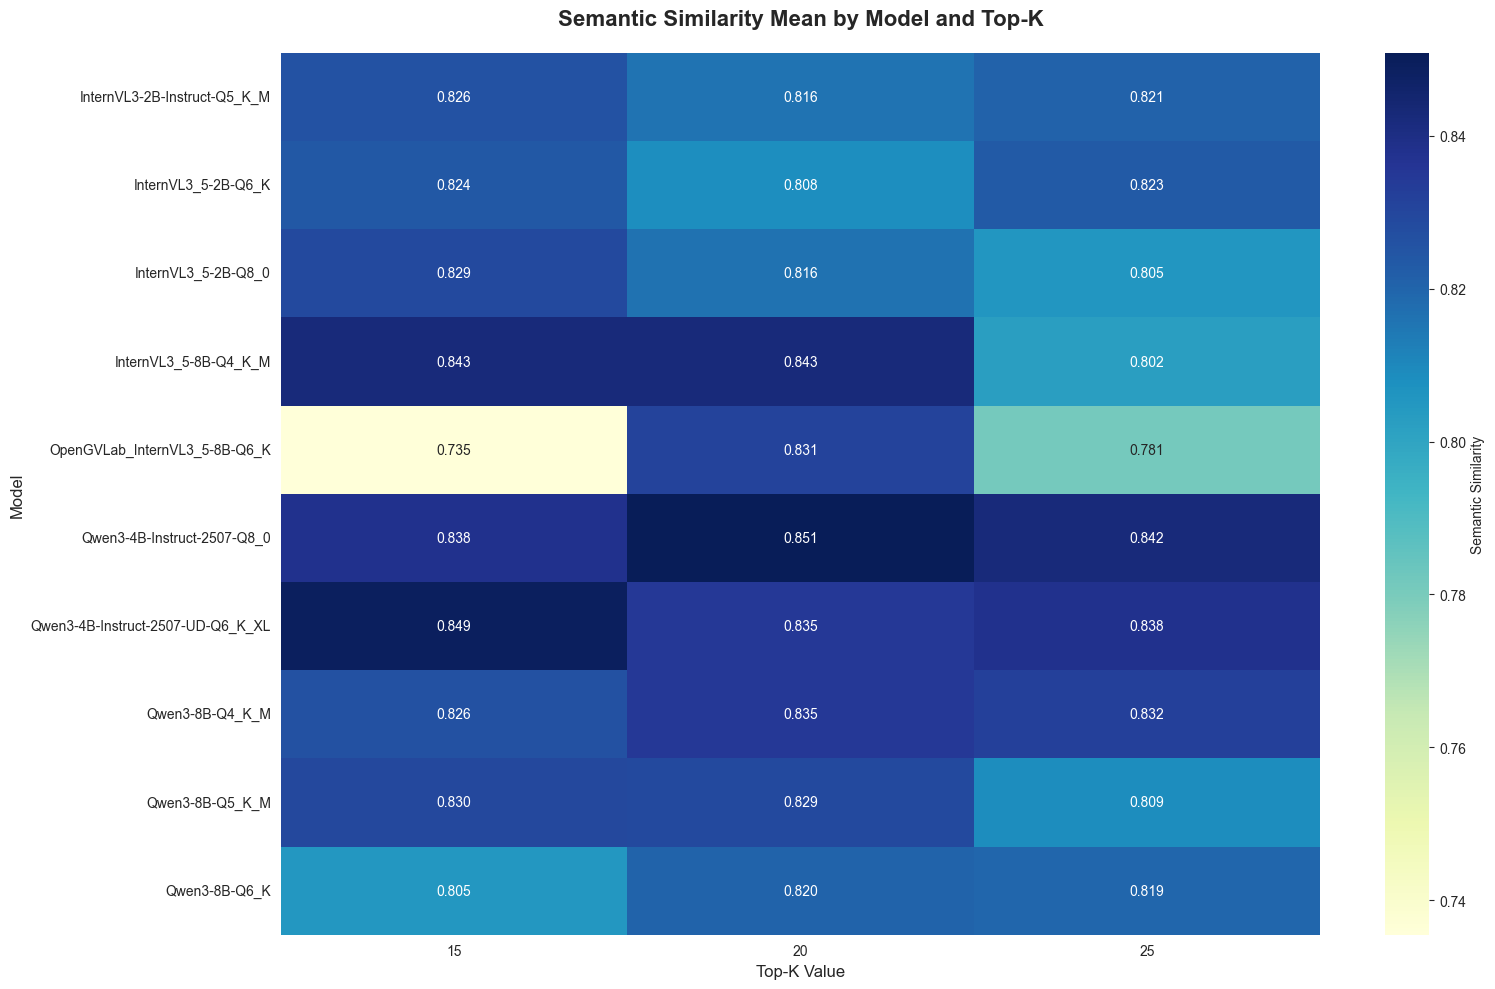

In [8]:
plt.figure(figsize=(16, 10))
pivot_sem = df_latest.pivot_table(values='semantic_sim_mean', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_sem, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Semantic Similarity'})
plt.title('Semantic Similarity Mean by Model and Top-K', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top-K Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

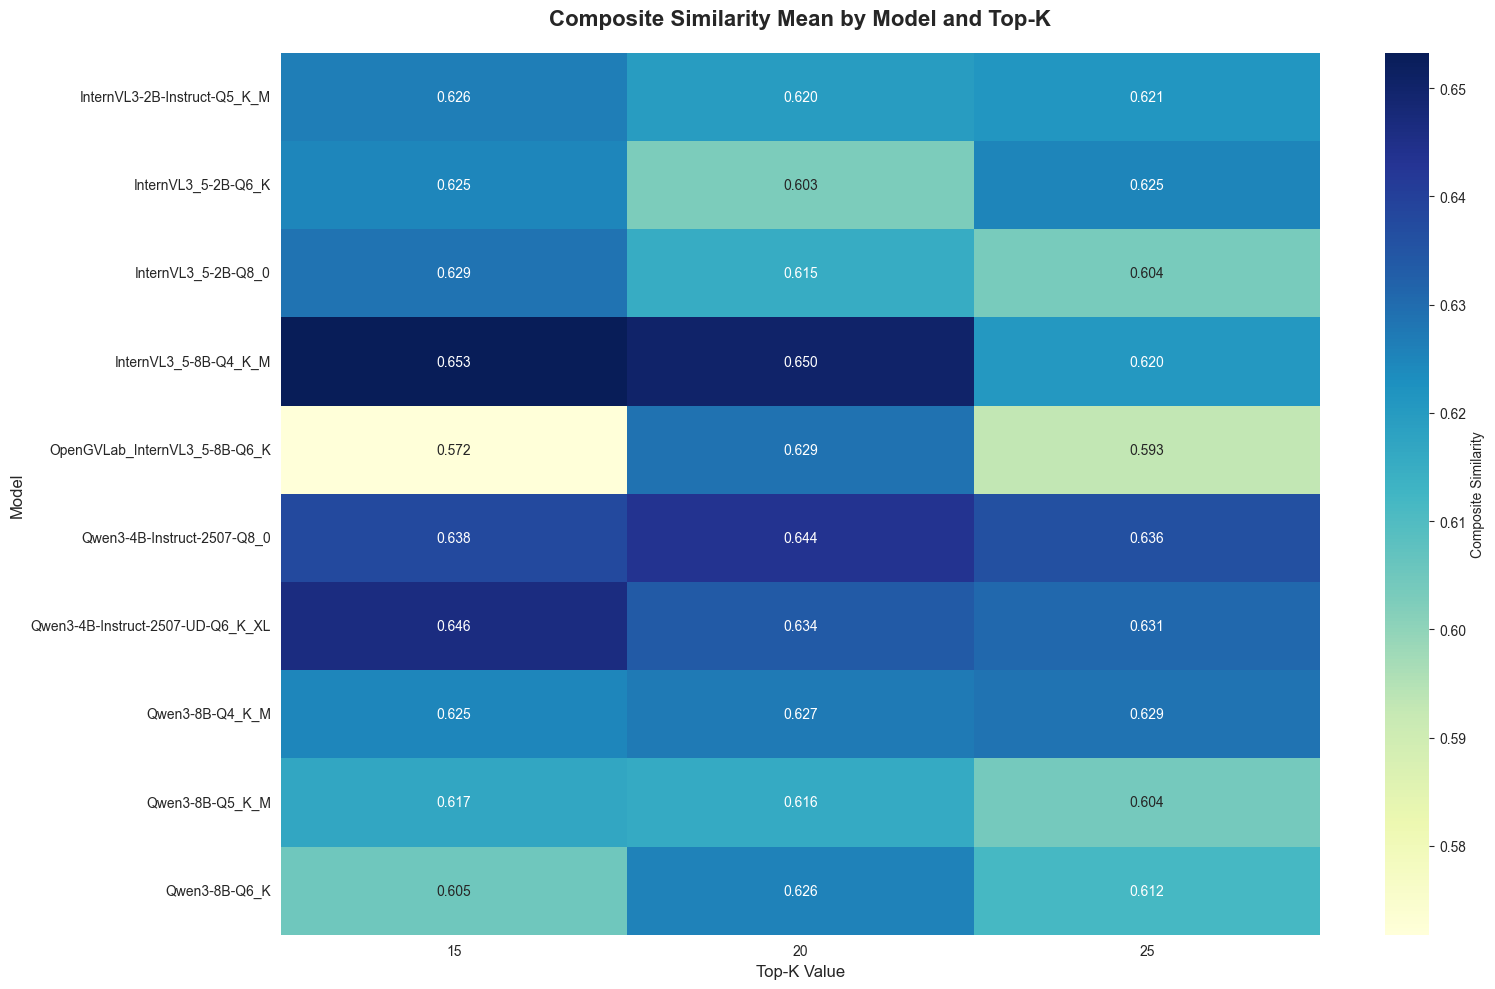

In [9]:
plt.figure(figsize=(16, 10))
pivot_sem = df_latest.pivot_table(values='composite_score', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_sem, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Composite Similarity'})
plt.title('Composite Similarity Mean by Model and Top-K', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top-K Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

# Add composite score to df_latest_all (needed for dataset comparison analysis)
df_latest_all['composite_score'] = (
    df_latest_all['semantic_sim_mean'] * 0.6 +
    df_latest_all['tfidf_mean'] * 0.2 +
    df_latest_all['bleu_mean'] * 0.2

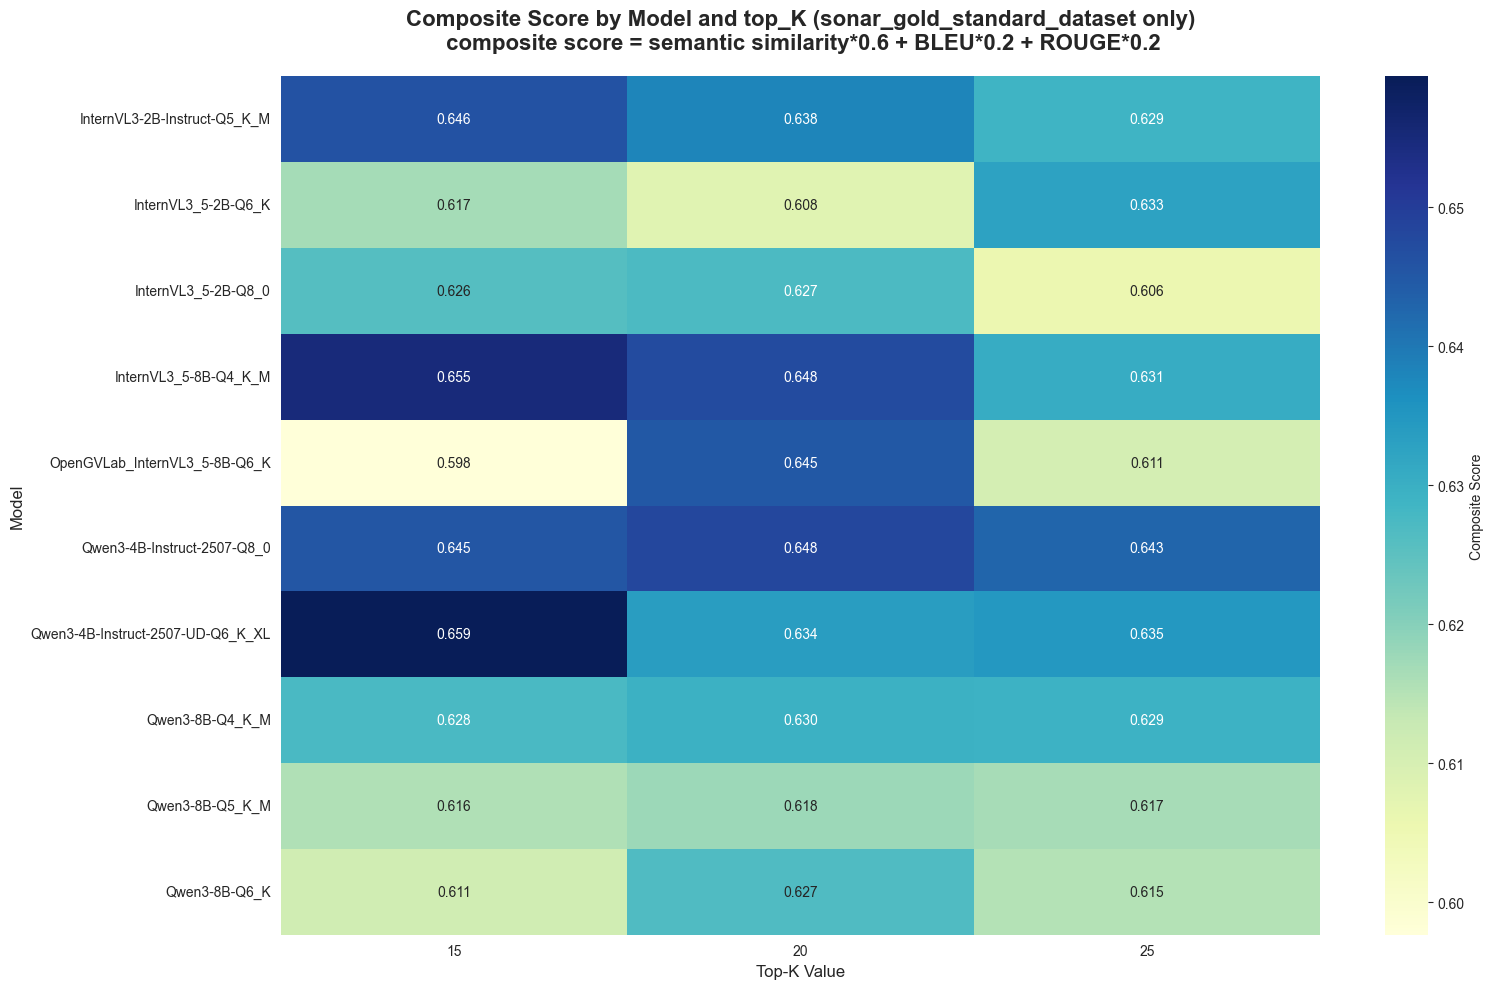


Showing data for 30 configurations from sonar_gold_standard_dataset


In [10]:
# Heatmap for specific dataset: sonar_gold_standard_dataset only
df_sonar = df_latest[df_latest['gold_standard_path'].str.contains('sonar_gold_standard_dataset', case=False, na=False)]

plt.figure(figsize=(16, 10))
pivot_sem = df_sonar.pivot_table(values='composite_score', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_sem, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Composite Score'})
plt.title('Composite Score by Model and top_K (sonar_gold_standard_dataset only)\n composite score = semantic similarity*0.6 + BLEU*0.2 + ROUGE*0.2', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top-K Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nShowing data for {len(df_sonar)} configurations from sonar_gold_standard_dataset")

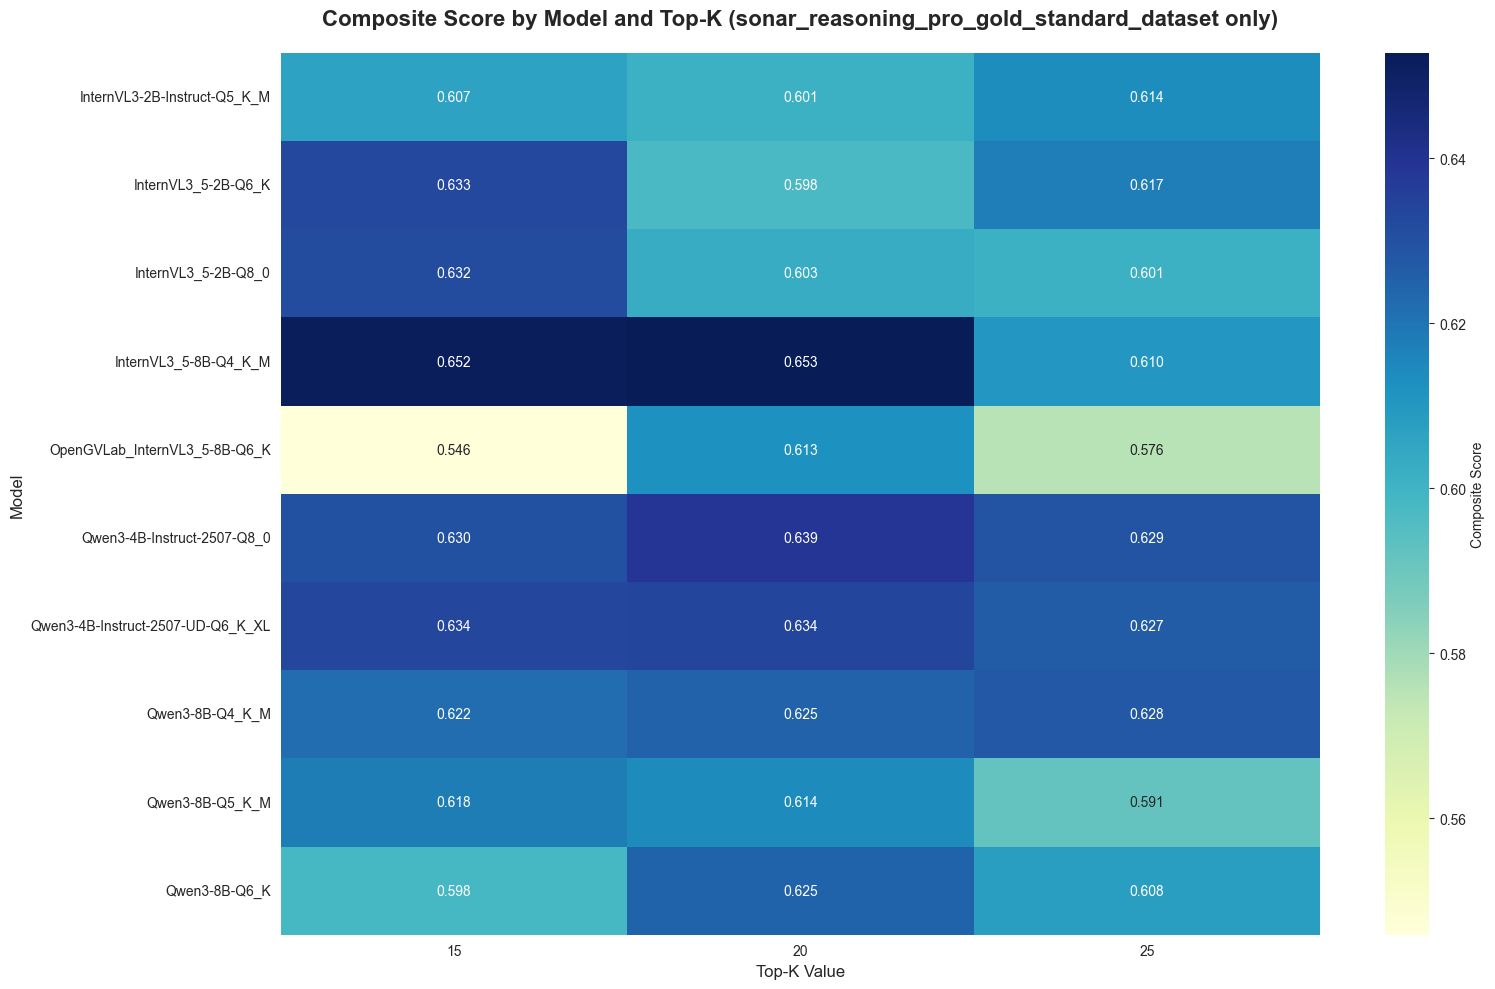


Showing data for 30 configurations from sonar_gold_standard_dataset


In [11]:
# Heatmap for specific dataset: sonar_reasoning_pro_gold_standard_dataset only
df_sonar = df_latest[df_latest['gold_standard_path'].str.contains('sonar_reasoning_pro_gold_standard_dataset', case=False, na=False)]

plt.figure(figsize=(16, 10))
pivot_sem = df_sonar.pivot_table(values='composite_score', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_sem, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Composite Score'})
plt.title('Composite Score by Model and Top-K (sonar_reasoning_pro_gold_standard_dataset only)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top-K Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nShowing data for {len(df_sonar)} configurations from sonar_gold_standard_dataset")

### 8.2 Response Time Heatmap

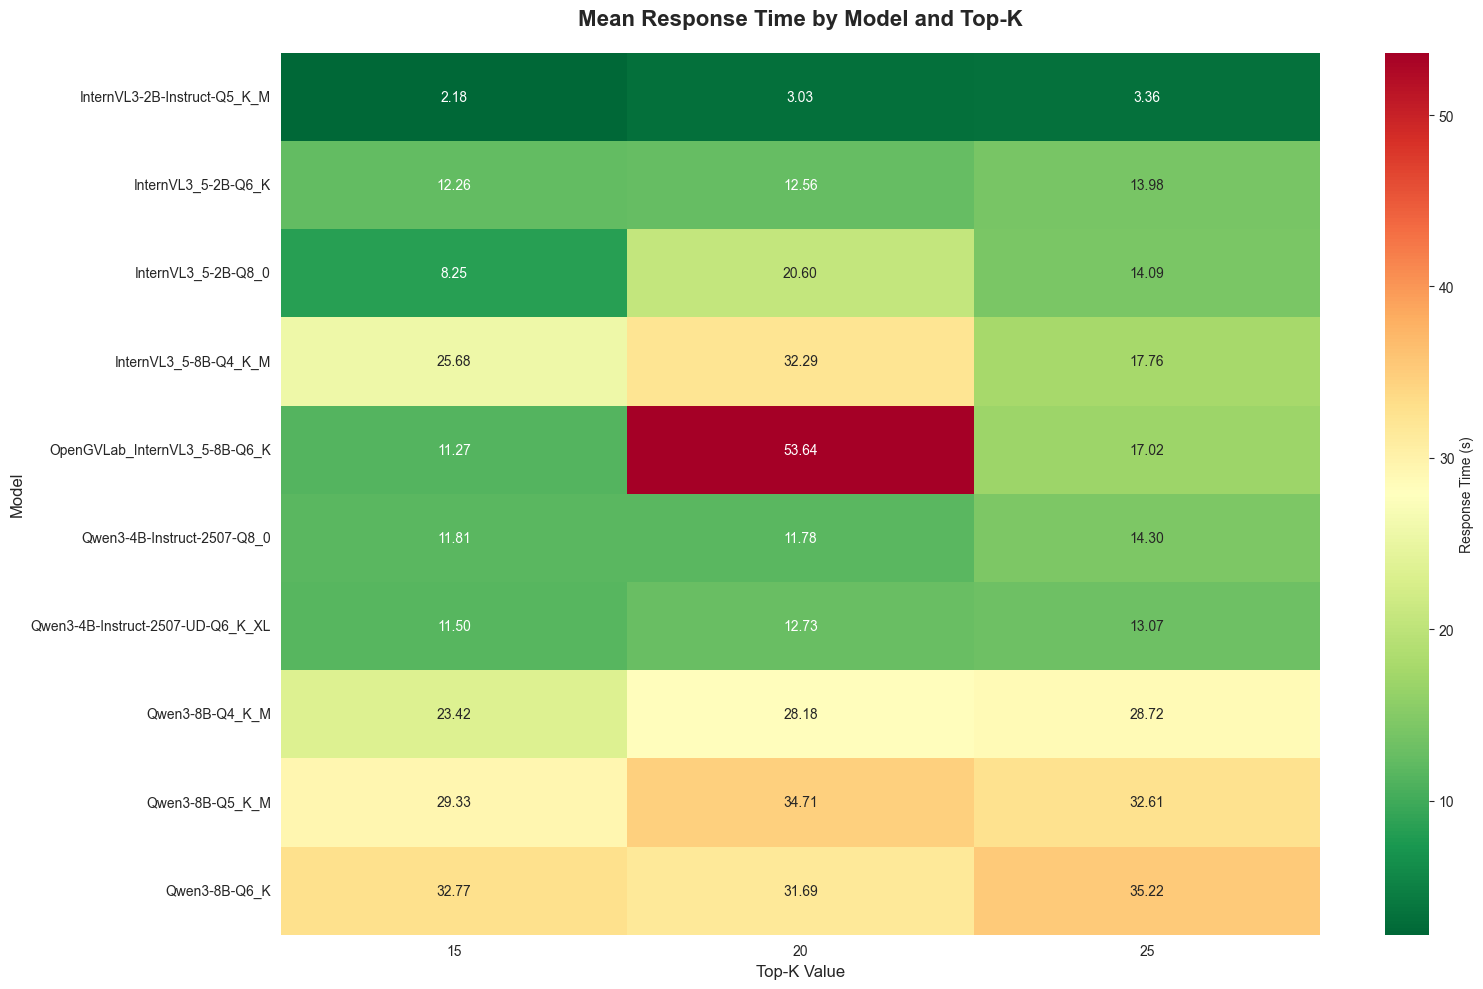

In [12]:
plt.figure(figsize=(16, 10))
pivot_time = df_latest.pivot_table(values='response_time_mean', index='model', columns='top_k', aggfunc='mean')
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='RdYlGn_r', cbar_kws={'label': 'Response Time (s)'})
plt.title('Mean Response Time by Model and Top-K', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Top-K Value', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

### 8.3 Model Performance Ranking

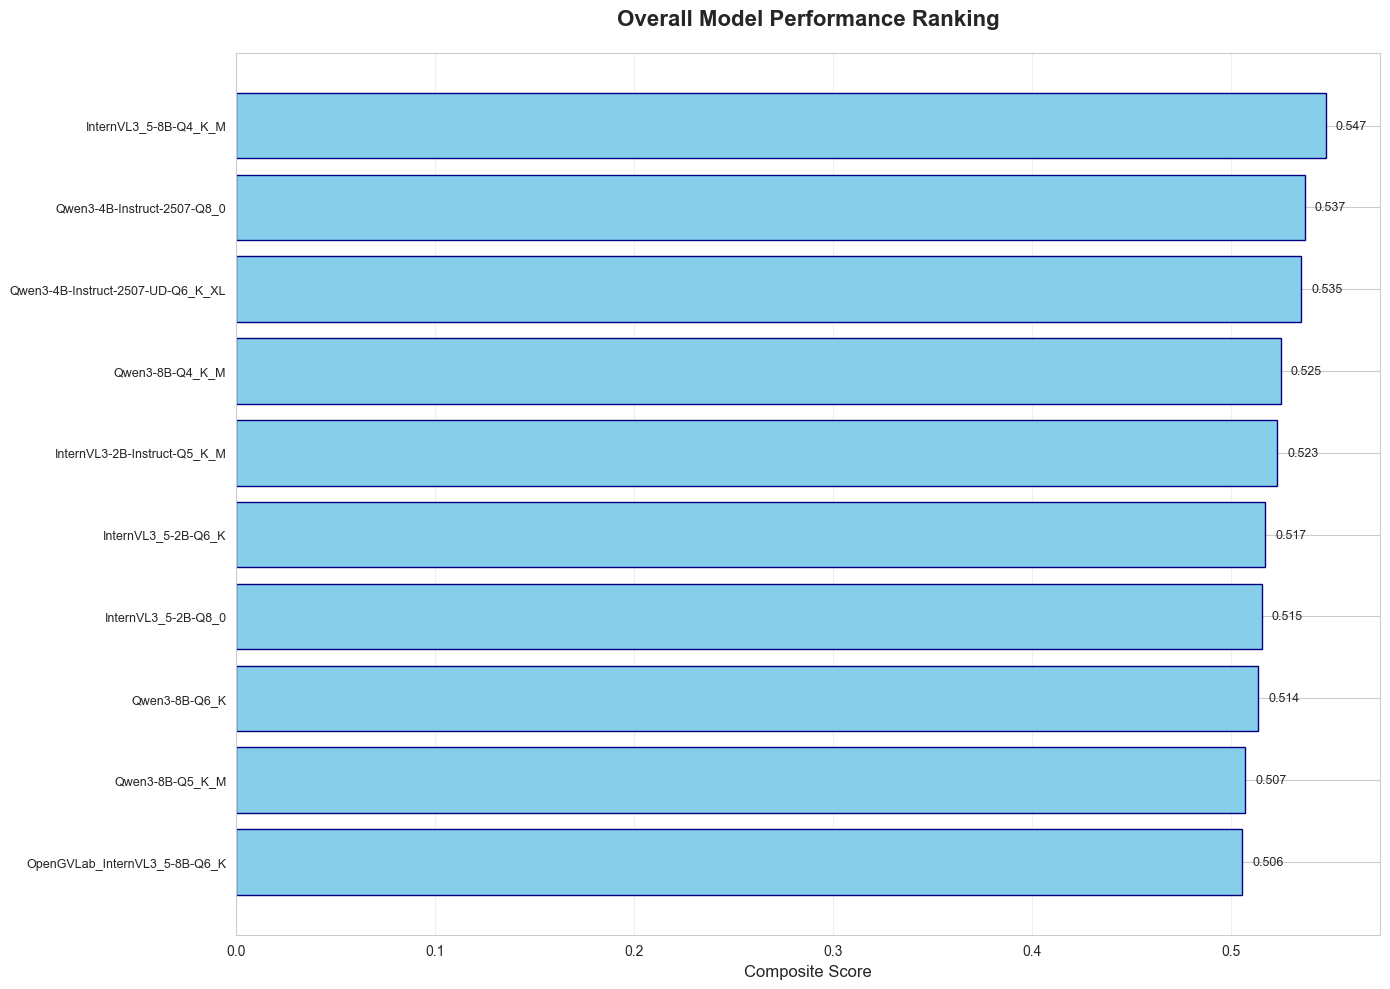

In [13]:
plt.figure(figsize=(14, 10))

model_scores = df_latest.groupby('model').agg({
    'semantic_sim_mean': 'mean',
    'bleu_mean': 'mean',
    'tfidf_mean': 'mean'
}).reset_index()

model_scores['composite_score'] = (
    model_scores['semantic_sim_mean'] * 0.4 +
    model_scores['tfidf_mean'] * 0.3 +
    model_scores['bleu_mean'] * 0.3
)

model_scores = model_scores.sort_values('composite_score', ascending=True)

y_pos = np.arange(len(model_scores))
plt.barh(y_pos, model_scores['composite_score'], color='skyblue', edgecolor='navy')
plt.yticks(y_pos, model_scores['model'], fontsize=9)
plt.xlabel('Composite Score', fontsize=12)
plt.title('Overall Model Performance Ranking', fontsize=16, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(model_scores['composite_score']):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 8.4 Multi-Metric Comparison for Top Models

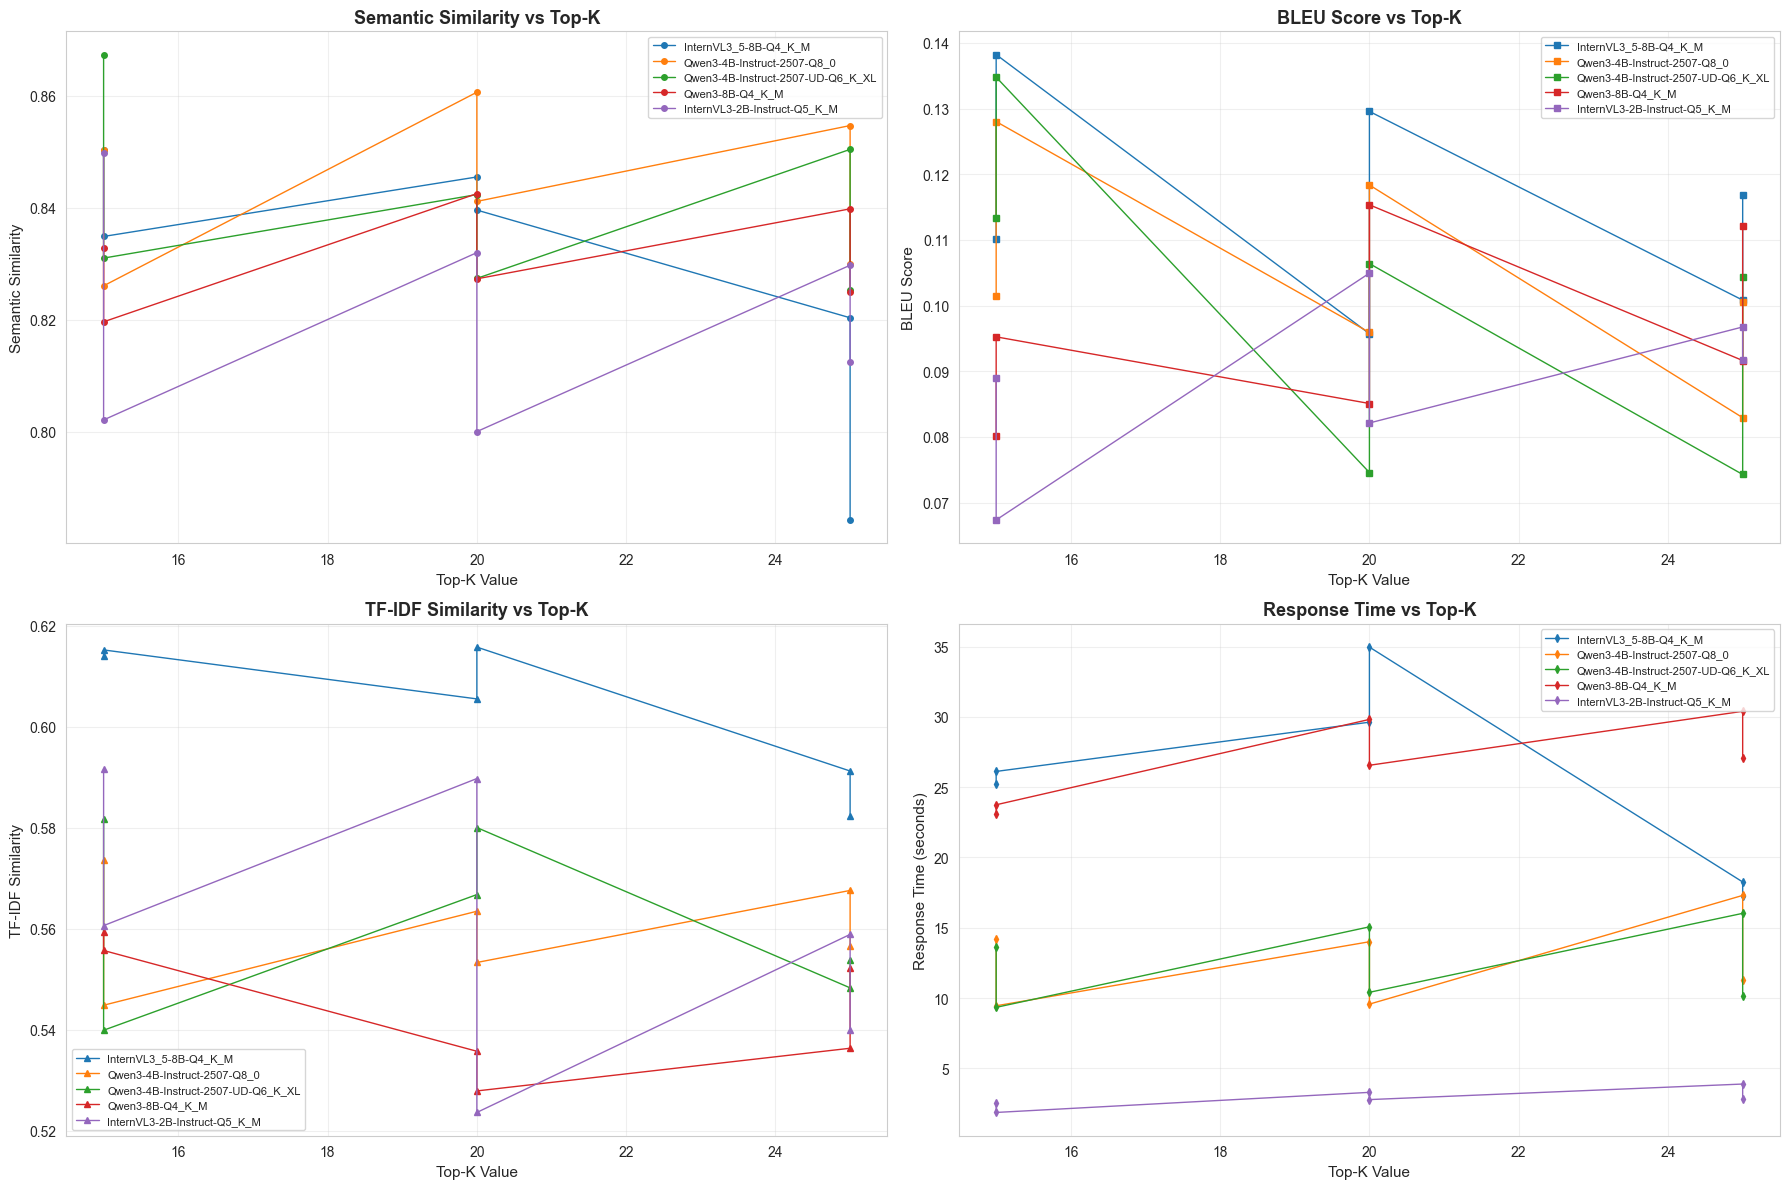

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Get top 5 models by composite score
top_models = df_latest.groupby('model')['composite_score'].mean().nlargest(5).index
df_top = df_latest[df_latest['model'].isin(top_models)]

# Semantic Similarity vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[0, 0].plot(model_data['top_k'], model_data['semantic_sim_mean'], 
                    marker='o', label=model, linewidth=1, markersize=4)
axes[0, 0].set_title('Semantic Similarity vs Top-K', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Top-K Value', fontsize=11)
axes[0, 0].set_ylabel('Semantic Similarity', fontsize=11)
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# BLEU Score vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[0, 1].plot(model_data['top_k'], model_data['bleu_mean'], 
                    marker='s', label=model, linewidth=1, markersize=4)
axes[0, 1].set_title('BLEU Score vs Top-K', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Top-K Value', fontsize=11)
axes[0, 1].set_ylabel('BLEU Score', fontsize=11)
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3)

# TF-IDF Similarity vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[1, 0].plot(model_data['top_k'], model_data['tfidf_mean'], 
                    marker='^', label=model, linewidth=1, markersize=4)
axes[1, 0].set_title('TF-IDF Similarity vs Top-K', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Top-K Value', fontsize=11)
axes[1, 0].set_ylabel('TF-IDF Similarity', fontsize=11)
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Response Time vs Top-K
for model in top_models:
    model_data = df_top[df_top['model'] == model].sort_values('top_k')
    axes[1, 1].plot(model_data['top_k'], model_data['response_time_mean'], 
                    marker='d', label=model, linewidth=1, markersize=4)
axes[1, 1].set_title('Response Time vs Top-K', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Top-K Value', fontsize=11)
axes[1, 1].set_ylabel('Response Time (seconds)', fontsize=11)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.5 Distribution Plots

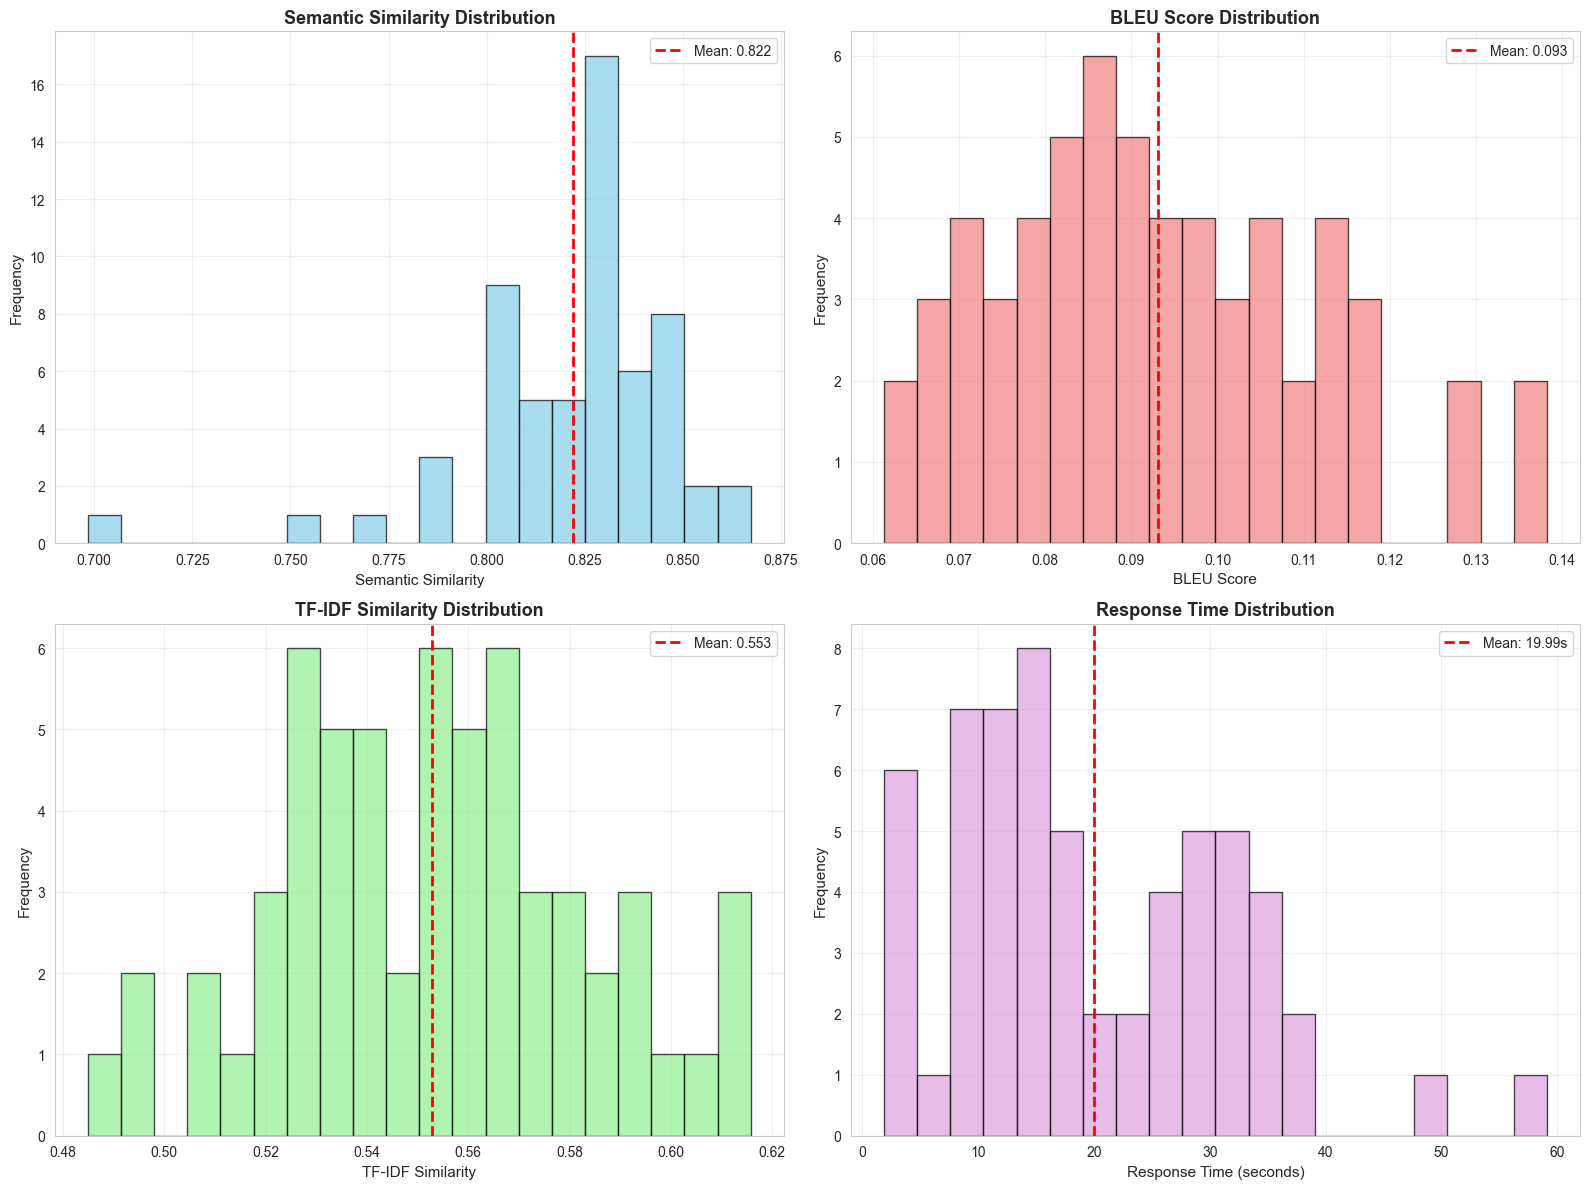

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Semantic Similarity Distribution
axes[0, 0].hist(df_latest['semantic_sim_mean'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_latest['semantic_sim_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['semantic_sim_mean'].mean():.3f}")
axes[0, 0].set_title('Semantic Similarity Distribution', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Semantic Similarity', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# BLEU Score Distribution
axes[0, 1].hist(df_latest['bleu_mean'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(df_latest['bleu_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['bleu_mean'].mean():.3f}")
axes[0, 1].set_title('BLEU Score Distribution', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('BLEU Score', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# TF-IDF Distribution
axes[1, 0].hist(df_latest['tfidf_mean'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df_latest['tfidf_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['tfidf_mean'].mean():.3f}")
axes[1, 0].set_title('TF-IDF Similarity Distribution', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('TF-IDF Similarity', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Response Time Distribution
axes[1, 1].hist(df_latest['response_time_mean'], bins=20, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].axvline(df_latest['response_time_mean'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {df_latest['response_time_mean'].mean():.2f}s")
axes[1, 1].set_title('Response Time Distribution', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Response Time (seconds)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.6 Box Plots by Top-K

### 8.7 Distribution Analysis by Model

Visualize metric distributions for each individual model.

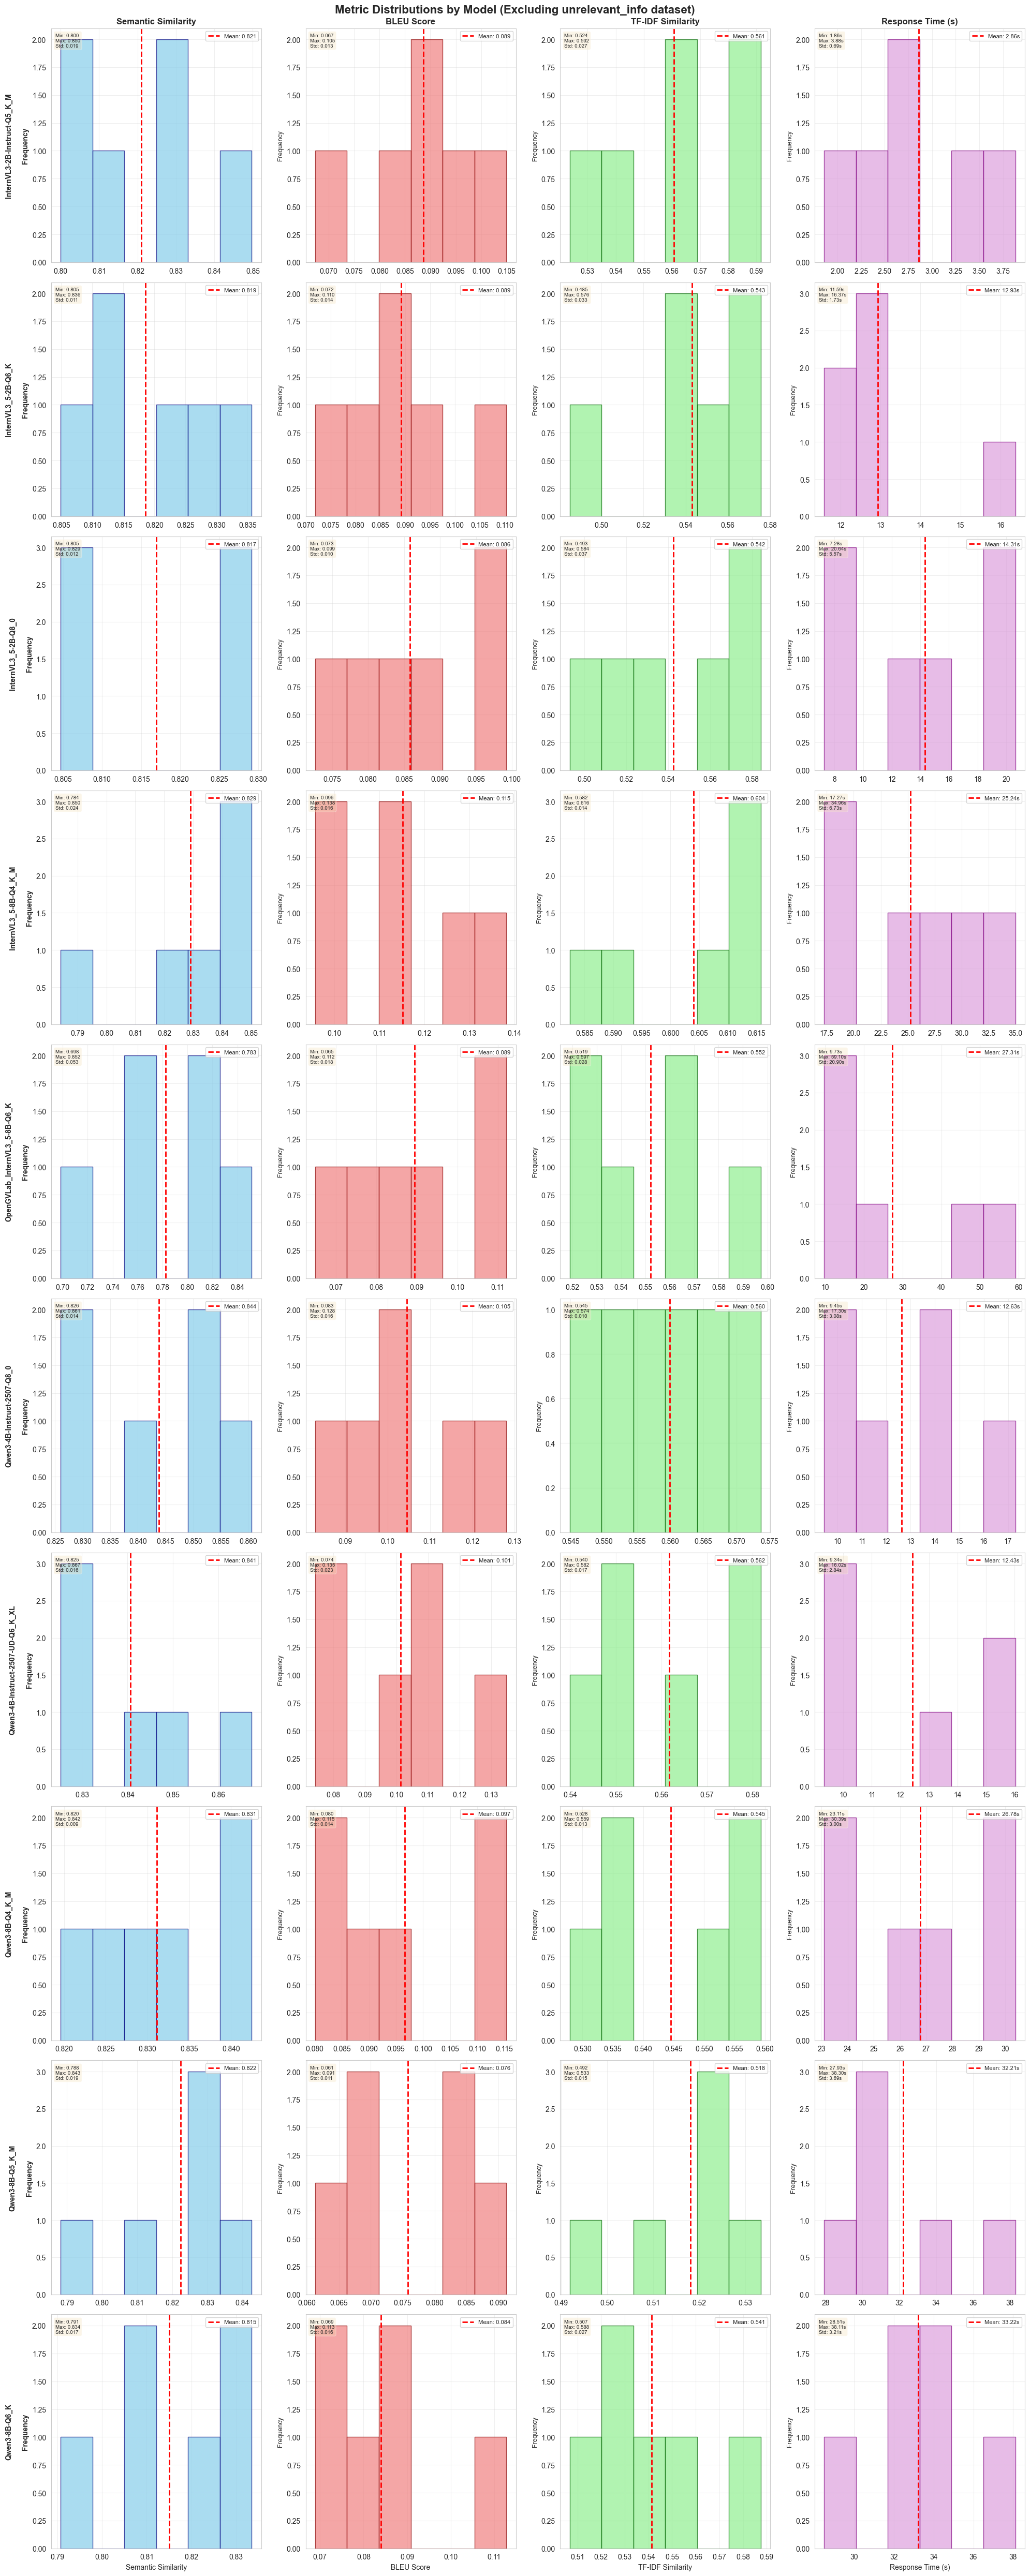


Distribution analysis completed for 10 models


In [16]:
# Get all unique models
all_models = sorted(df_latest['model'].unique())
n_models = len(all_models)

# Create subplots - 4 metrics per model
fig, axes = plt.subplots(n_models, 4, figsize=(20, 5*n_models))

# If only one model, ensure axes is 2D
if n_models == 1:
    axes = axes.reshape(1, -1)

metrics_info = [
    ('semantic_sim_mean', 'Semantic Similarity', 'skyblue', 'navy'),
    ('bleu_mean', 'BLEU Score', 'lightcoral', 'darkred'),
    ('tfidf_mean', 'TF-IDF Similarity', 'lightgreen', 'darkgreen'),
    ('response_time_mean', 'Response Time (s)', 'plum', 'purple')
]

for model_idx, model in enumerate(all_models):
    model_data = df_latest[df_latest['model'] == model]
    
    for metric_idx, (metric, label, color, edge_color) in enumerate(metrics_info):
        ax = axes[model_idx, metric_idx]
        
        # Plot histogram
        values = model_data[metric].dropna()
        ax.hist(values, bins=min(15, len(values)), color=color, edgecolor=edge_color, alpha=0.7)
        
        # Add mean line
        mean_val = values.mean()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {mean_val:.3f}' if metric != 'response_time_mean' else f'Mean: {mean_val:.2f}s')
        
        # Formatting
        if metric_idx == 0:
            ax.set_ylabel(f'{model}\n\nFrequency', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('Frequency', fontsize=9)
        
        if model_idx == 0:
            ax.set_title(label, fontsize=12, fontweight='bold')
        
        if model_idx == n_models - 1:
            ax.set_xlabel(label, fontsize=10)
        
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'Min: {values.min():.3f}\nMax: {values.max():.3f}\nStd: {values.std():.3f}'
        if metric == 'response_time_mean':
            stats_text = f'Min: {values.min():.2f}s\nMax: {values.max():.2f}s\nStd: {values.std():.2f}s'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                fontsize=7, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Metric Distributions by Model (Excluding unrelevant_info dataset)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print(f"Distribution analysis completed for {n_models} models")
print(f"{'='*80}")

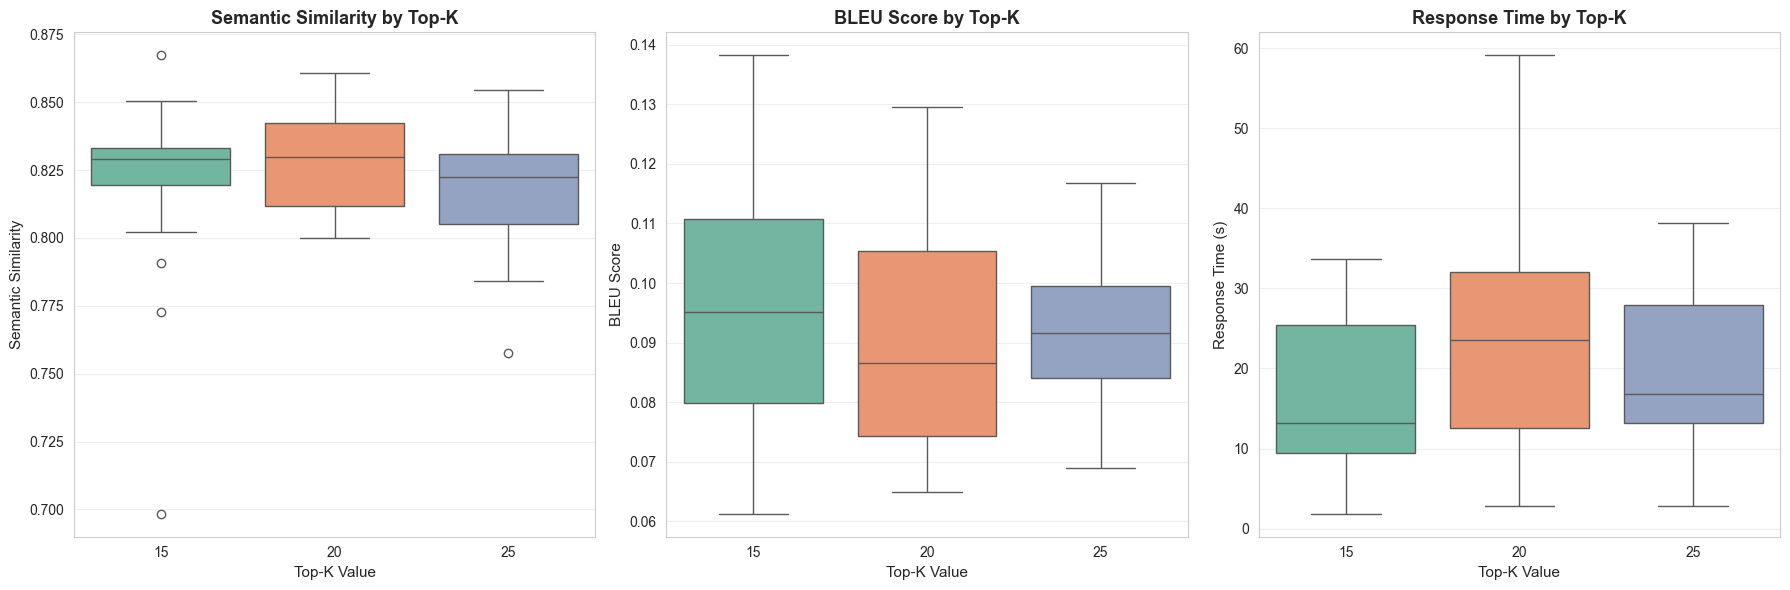

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Semantic Similarity by Top-K
sns.boxplot(data=df_latest, x='top_k', y='semantic_sim_mean', ax=axes[0], palette='Set2')
axes[0].set_title('Semantic Similarity by Top-K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Top-K Value', fontsize=11)
axes[0].set_ylabel('Semantic Similarity', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')

# BLEU Score by Top-K
sns.boxplot(data=df_latest, x='top_k', y='bleu_mean', ax=axes[1], palette='Set2')
axes[1].set_title('BLEU Score by Top-K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Top-K Value', fontsize=11)
axes[1].set_ylabel('BLEU Score', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# Response Time by Top-K
sns.boxplot(data=df_latest, x='top_k', y='response_time_mean', ax=axes[2], palette='Set2')
axes[2].set_title('Response Time by Top-K', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Top-K Value', fontsize=11)
axes[2].set_ylabel('Response Time (s)', fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Export Results

Save the analysis results to CSV files for further use.

In [18]:
# Export latest configurations summary
output_file = 'analysis_results_summary.csv'
df_latest.to_csv(output_file, index=False)
print(f"✓ Latest configurations saved to: {output_file}")

# Export top configurations
top_configs = df_latest.nlargest(10, 'composite_score')[['model', 'top_k', 'semantic_sim_mean', 
                                                          'bleu_mean', 'tfidf_mean', 
                                                          'response_time_mean', 'composite_score']]
top_configs.to_csv('top_10_configurations.csv', index=False)
print(f"✓ Top 10 configurations saved to: top_10_configurations.csv")

# Export model rankings
model_ranking = df_latest.groupby('model').agg({
    'semantic_sim_mean': 'mean',
    'bleu_mean': 'mean',
    'tfidf_mean': 'mean',
    'response_time_mean': 'mean',
    'composite_score': 'mean'
}).round(4).sort_values('composite_score', ascending=False)

model_ranking.to_csv('model_rankings.csv')
print(f"✓ Model rankings saved to: model_rankings.csv")

print("\n" + "="*80)
print("All results exported successfully!")
print("="*80)

✓ Latest configurations saved to: analysis_results_summary.csv
✓ Top 10 configurations saved to: top_10_configurations.csv
✓ Model rankings saved to: model_rankings.csv

All results exported successfully!


## 10. Summary and Conclusions

Key findings from the analysis.

In [19]:
best_config = df_latest.nlargest(1, 'composite_score').iloc[0]

print("="*80)
print("ANALYSIS SUMMARY")
print("="*80)
print(f"\n📊 Total Experiments Analyzed: {len(df_all)}")
print(f"📊 Unique Models Tested: {df_all['model'].nunique()}")
print(f"📊 Top-K Values Tested: {sorted(df_latest['top_k'].unique())}")
print(f"📊 Latest Unique Configurations: {len(df_latest)}")

print("\n" + "="*80)
print("🏆 BEST CONFIGURATION")
print("="*80)
print(f"Model: {best_config['model']}")
print(f"Top-K: {best_config['top_k']}")
print(f"Semantic Similarity: {best_config['semantic_sim_mean']:.4f}")
print(f"BLEU Score: {best_config['bleu_mean']:.4f}")
print(f"TF-IDF Similarity: {best_config['tfidf_mean']:.4f}")
print(f"Response Time: {best_config['response_time_mean']:.2f} seconds")
print(f"Composite Score: {best_config['composite_score']:.4f}")

print("\n" + "="*80)
print("📈 KEY INSIGHTS")
print("="*80)
print(f"• Semantic Similarity Range: {df_latest['semantic_sim_mean'].min():.4f} - {df_latest['semantic_sim_mean'].max():.4f}")
print(f"• Average Semantic Similarity: {df_latest['semantic_sim_mean'].mean():.4f}")
print(f"• BLEU Score Range: {df_latest['bleu_mean'].min():.4f} - {df_latest['bleu_mean'].max():.4f}")
print(f"• Average BLEU Score: {df_latest['bleu_mean'].mean():.4f}")
print(f"• Response Time Range: {df_latest['response_time_mean'].min():.2f}s - {df_latest['response_time_mean'].max():.2f}s")
print(f"• Average Response Time: {df_latest['response_time_mean'].mean():.2f}s")

# Top-K impact
print("\n" + "="*80)
print("🎯 TOP-K VALUE IMPACT")
print("="*80)
topk_impact = df_latest.groupby('top_k')['semantic_sim_mean'].mean().sort_values(ascending=False)
print("\nBest Top-K values by Semantic Similarity:")
for topk, score in topk_impact.head(3).items():
    print(f"  • Top-K {topk}: {score:.4f}")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

ANALYSIS SUMMARY

📊 Total Experiments Analyzed: 86
📊 Unique Models Tested: 10
📊 Top-K Values Tested: [np.int64(15), np.int64(20), np.int64(25)]
📊 Latest Unique Configurations: 60

🏆 BEST CONFIGURATION
Model: Qwen3-4B-Instruct-2507-UD-Q6_K_XL
Top-K: 15
Semantic Similarity: 0.8673
BLEU Score: 0.1133
TF-IDF Similarity: 0.5818
Response Time: 13.66 seconds
Composite Score: 0.6594

📈 KEY INSIGHTS
• Semantic Similarity Range: 0.6984 - 0.8673
• Average Semantic Similarity: 0.8221
• BLEU Score Range: 0.0613 - 0.1382
• Average BLEU Score: 0.0931
• Response Time Range: 1.86s - 59.10s
• Average Response Time: 19.99s

🎯 TOP-K VALUE IMPACT

Best Top-K values by Semantic Similarity:
  • Top-K 20: 0.8285
  • Top-K 15: 0.8205
  • Top-K 25: 0.8174

✅ ANALYSIS COMPLETE


---

# Golden Dataset Comparison Analysis

Compare performance across different golden standard datasets to understand how reference data affects evaluation metrics.

## 11. Identify Golden Datasets

First, let's identify all unique golden standard datasets used in the evaluations.

In [20]:
# For dataset comparison, use ALL datasets including unrelevant_info
# (We filtered it out for general analysis above)
unique_gold_datasets = df_latest_all['gold_standard_path'].unique()

print("\n⚠️ Note: Now including ALL golden datasets for comparison analysis")
print("   (including unrelevant_info_standard_dataset that was excluded earlier)\n")

print("="*80)
print("GOLDEN STANDARD DATASETS FOUND")
print("="*80)

for i, path in enumerate(unique_gold_datasets, 1):
    count_all = len(df_all[df_all['gold_standard_path'] == path])
    count_latest = len(df_latest_all[df_latest_all['gold_standard_path'] == path])
    
    # Extract dataset name from path
    dataset_name = Path(path).stem if path else "Unknown"
    
    print(f"\n{i}. {dataset_name}")
    print(f"   Path: {path}")
    print(f"   Total experiments: {count_all}")
    print(f"   Latest unique configs: {count_latest}")

# Create a simplified name for each dataset for easier analysis
def get_dataset_name(path):
    if pd.isna(path) or not path:
        return "Unknown"
    return Path(path).stem

df_all['dataset_name'] = df_all['gold_standard_path'].apply(get_dataset_name)
df_latest['dataset_name'] = df_latest['gold_standard_path'].apply(get_dataset_name)
df_latest_all['dataset_name'] = df_latest_all['gold_standard_path'].apply(get_dataset_name)

print("\n" + "="*80)
print(f"Total unique golden datasets: {len(unique_gold_datasets)}")
print("="*80)


⚠️ Note: Now including ALL golden datasets for comparison analysis
   (including unrelevant_info_standard_dataset that was excluded earlier)

GOLDEN STANDARD DATASETS FOUND

1. sonar_gold_standard_dataset
   Path: data/test/sonar_gold_standard_dataset.json
   Total experiments: 50
   Latest unique configs: 50

2. sonar_reasoning_pro_gold_standard_dataset
   Path: data/test/sonar_reasoning_pro_gold_standard_dataset.json
   Total experiments: 30
   Latest unique configs: 30

3. unrelevant_info_standard_dataset
   Path: data/test/unrelevant_info_standard_dataset.json
   Total experiments: 6
   Latest unique configs: 3

Total unique golden datasets: 3


## 12. Statistical Comparison by Golden Dataset

Compare key metrics across different golden datasets.

In [21]:
if len(unique_gold_datasets) > 1:
    print("="*80)
    print("PERFORMANCE METRICS BY GOLDEN DATASET")
    print("="*80)
    
    # Use df_latest_all to include ALL datasets for comparison
    # Aggregate statistics by golden dataset
    dataset_comparison = df_latest_all.groupby('dataset_name').agg({
        'semantic_sim_mean': ['mean', 'std', 'min', 'max', 'count'],
        'bleu_mean': ['mean', 'std', 'min', 'max'],
        'tfidf_mean': ['mean', 'std', 'min', 'max'],
        'response_time_mean': ['mean', 'std', 'min', 'max'],
        'composite_score': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    display(dataset_comparison)
    
    # Summary table
    print("\n" + "="*80)
    print("SUMMARY COMPARISON")
    print("="*80)
    
    summary = df_latest_all.groupby('dataset_name')[['semantic_sim_mean', 'bleu_mean', 
                                                   'tfidf_mean', 'response_time_mean', 
                                                   'composite_score']].mean().round(4)
    display(summary)
    
    # Best configuration per dataset
    print("\n" + "="*80)
    print("BEST CONFIGURATION PER GOLDEN DATASET")
    print("="*80)
    
    for dataset in df_latest_all['dataset_name'].unique():
        dataset_df = df_latest_all[df_latest_all['dataset_name'] == dataset]
        best = dataset_df.nlargest(1, 'composite_score').iloc[0]
        
        print(f"\n📊 Dataset: {dataset}")
        print(f"   Best Model: {best['model']}")
        print(f"   Top-K: {best['top_k']}")
        print(f"   Semantic Similarity: {best['semantic_sim_mean']:.4f}")
        print(f"   BLEU Score: {best['bleu_mean']:.4f}")
        print(f"   Composite Score: {best['composite_score']:.4f}")
        print(f"   Response Time: {best['response_time_mean']:.2f}s")
else:
    print("="*80)
    print("Only one golden dataset found in the logs.")
    print("No comparison needed.")
    print("="*80)

PERFORMANCE METRICS BY GOLDEN DATASET


semantic_sim_mean                  \
                                                       mean     std     min   
dataset_name                                                                  
sonar_gold_standard_dataset                          0.8324  0.0197  0.7726   
sonar_reasoning_pro_gold_standard_dataset            0.8103  0.0280  0.6984   
unrelevant_info_standard_dataset                     0.1549  0.0262  0.1301   

                                                        bleu_mean          \
                                              max count      mean     std   
dataset_name                                                                
sonar_gold_standard_dataset                0.8673    50    0.0844  0.0158   
sonar_reasoning_pro_gold_standard_dataset  0.8411    30    0.1004  0.0187   
unrelevant_info_standard_dataset           0.1823     3    0.0004  0.0004   

                                                          tfidf_mean  ...  \
                                              min     max       mean  ...   
dataset_name                                                          ...   
sonar_gold_standard_dataset                0.0538  0.1217     0.5575  ...   
sonar_reasoning_pro_gold_standard_dataset  0.0649  0.1382     0.5479  ...   
unrelevant_info_standard_dataset           0.0002  0.0009     0.0055  ...   

                                                          response_time_mean  \
                                              min     max               mean   
dataset_name                                                                   
sonar_gold_standard_dataset                0.4918  0.6139            20.8318   
sonar_reasoning_pro_gold_standard_dataset  0.4849  0.6157            18.9060   
unrelevant_info_standard_dataset           0.0027  0.0079            20.1244   

                                                                      \
                                               std      min      max   
dataset_name                                                           
sonar_gold_standard_dataset                11.2350   2.2329  48.1677   
sonar_reasoning_pro_gold_standard_dataset  12.5589   1.8597  59.1038   
unrelevant_info_standard_dataset           11.2477  13.0840  33.0964   

                                          composite_score                  \
                                                     mean     std     min   
dataset_name                                                                
sonar_gold_standard_dataset                        0.6278  0.0165  0.5912   
sonar_reasoning_pro_gold_standard_dataset          0.6159  0.0218  0.5459   
unrelevant_info_standard_dataset                   0.0941  0.0153  0.0793   

                                                   
                                              max  
dataset_name                                       
sonar_gold_standard_dataset                0.6594  
sonar_reasoning_pro_gold_standard_dataset  0.6528  
unrelevant_info_standard_dataset           0.1099  

[3 rows x 21 columns]


SUMMARY COMPARISON


,semantic_sim_mean,bleu_mean,tfidf_mean,response_time_mean,composite_score
dataset_name,,,,,
sonar_gold_standard_dataset,0.8324,0.0844,0.5575,20.8318,0.6278
sonar_reasoning_pro_gold_standard_dataset,0.8103,0.1004,0.5479,18.9060,0.6159
unrelevant_info_standard_dataset,0.1549,0.0004,0.0055,20.1244,0.0941



BEST CONFIGURATION PER GOLDEN DATASET

📊 Dataset: sonar_gold_standard_dataset
   Best Model: Qwen3-4B-Instruct-2507-UD-Q6_K_XL
   Top-K: 15
   Semantic Similarity: 0.8673
   BLEU Score: 0.1133
   Composite Score: 0.6594
   Response Time: 13.66s

📊 Dataset: sonar_reasoning_pro_gold_standard_dataset
   Best Model: InternVL3_5-8B-Q4_K_M
   Top-K: 20
   Semantic Similarity: 0.8396
   BLEU Score: 0.1296
   Composite Score: 0.6528
   Response Time: 34.96s

📊 Dataset: unrelevant_info_standard_dataset
   Best Model: Qwen3-4B-Instruct-2507-Q8_0
   Top-K: 20
   Semantic Similarity: 0.1823
   BLEU Score: 0.0002
   Composite Score: 0.1099
   Response Time: 14.19s


## 13. Visualizations: Golden Dataset Comparisons

Create visualizations comparing performance across different golden datasets.

### 13.1 Metric Comparison Bar Charts

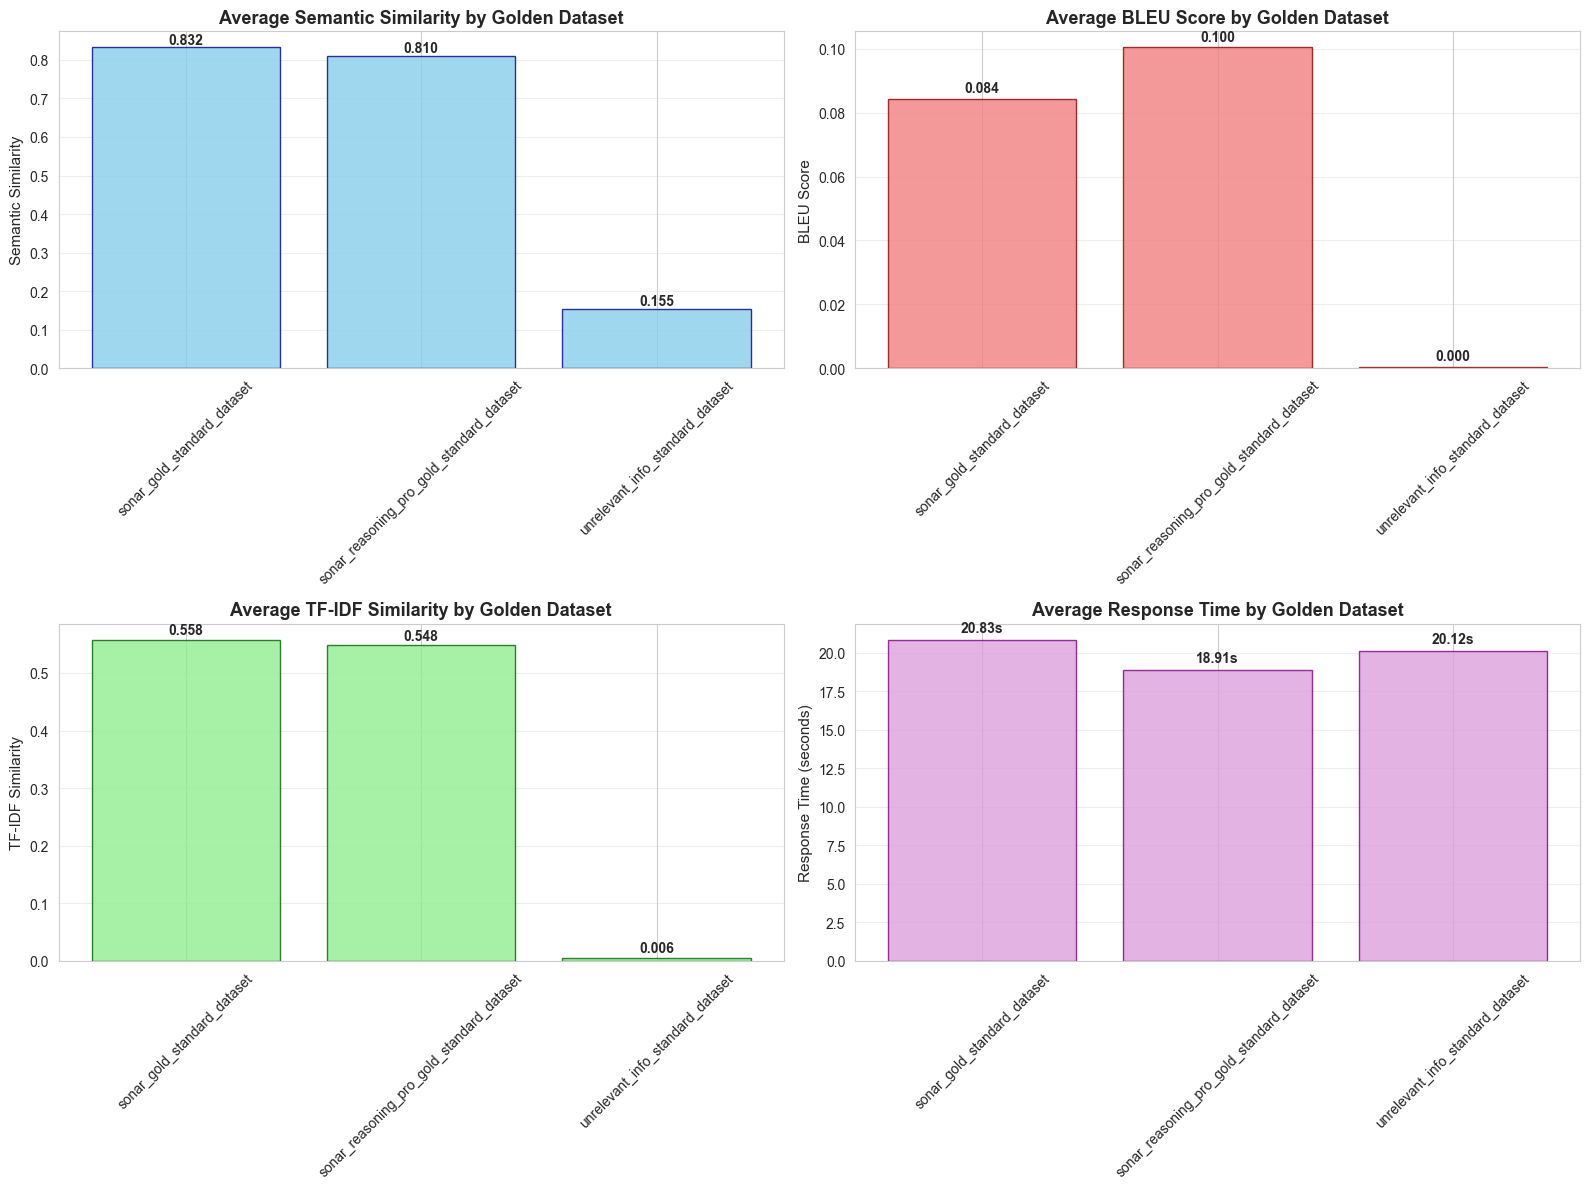

In [22]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    datasets_summary = df_latest_all.groupby('dataset_name').agg({
        'semantic_sim_mean': 'mean',
        'bleu_mean': 'mean',
        'tfidf_mean': 'mean',
        'response_time_mean': 'mean'
    }).reset_index()
    
    # Semantic Similarity
    axes[0, 0].bar(datasets_summary['dataset_name'], datasets_summary['semantic_sim_mean'], 
                   color='skyblue', edgecolor='navy', alpha=0.8)
    axes[0, 0].set_title('Average Semantic Similarity by Golden Dataset', fontsize=13, fontweight='bold')
    axes[0, 0].set_ylabel('Semantic Similarity', fontsize=11)
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['semantic_sim_mean']):
        axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # BLEU Score
    axes[0, 1].bar(datasets_summary['dataset_name'], datasets_summary['bleu_mean'], 
                   color='lightcoral', edgecolor='darkred', alpha=0.8)
    axes[0, 1].set_title('Average BLEU Score by Golden Dataset', fontsize=13, fontweight='bold')
    axes[0, 1].set_ylabel('BLEU Score', fontsize=11)
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['bleu_mean']):
        axes[0, 1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # TF-IDF Similarity
    axes[1, 0].bar(datasets_summary['dataset_name'], datasets_summary['tfidf_mean'], 
                   color='lightgreen', edgecolor='darkgreen', alpha=0.8)
    axes[1, 0].set_title('Average TF-IDF Similarity by Golden Dataset', fontsize=13, fontweight='bold')
    axes[1, 0].set_ylabel('TF-IDF Similarity', fontsize=11)
    axes[1, 0].tick_params(axis='x', rotation=45)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['tfidf_mean']):
        axes[1, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
    
    # Response Time
    axes[1, 1].bar(datasets_summary['dataset_name'], datasets_summary['response_time_mean'], 
                   color='plum', edgecolor='purple', alpha=0.8)
    axes[1, 1].set_title('Average Response Time by Golden Dataset', fontsize=13, fontweight='bold')
    axes[1, 1].set_ylabel('Response Time (seconds)', fontsize=11)
    axes[1, 1].tick_params(axis='x', rotation=45)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(datasets_summary['response_time_mean']):
        axes[1, 1].text(i, v + 0.5, f'{v:.2f}s', ha='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 13.2 Box Plot Comparison Across Datasets

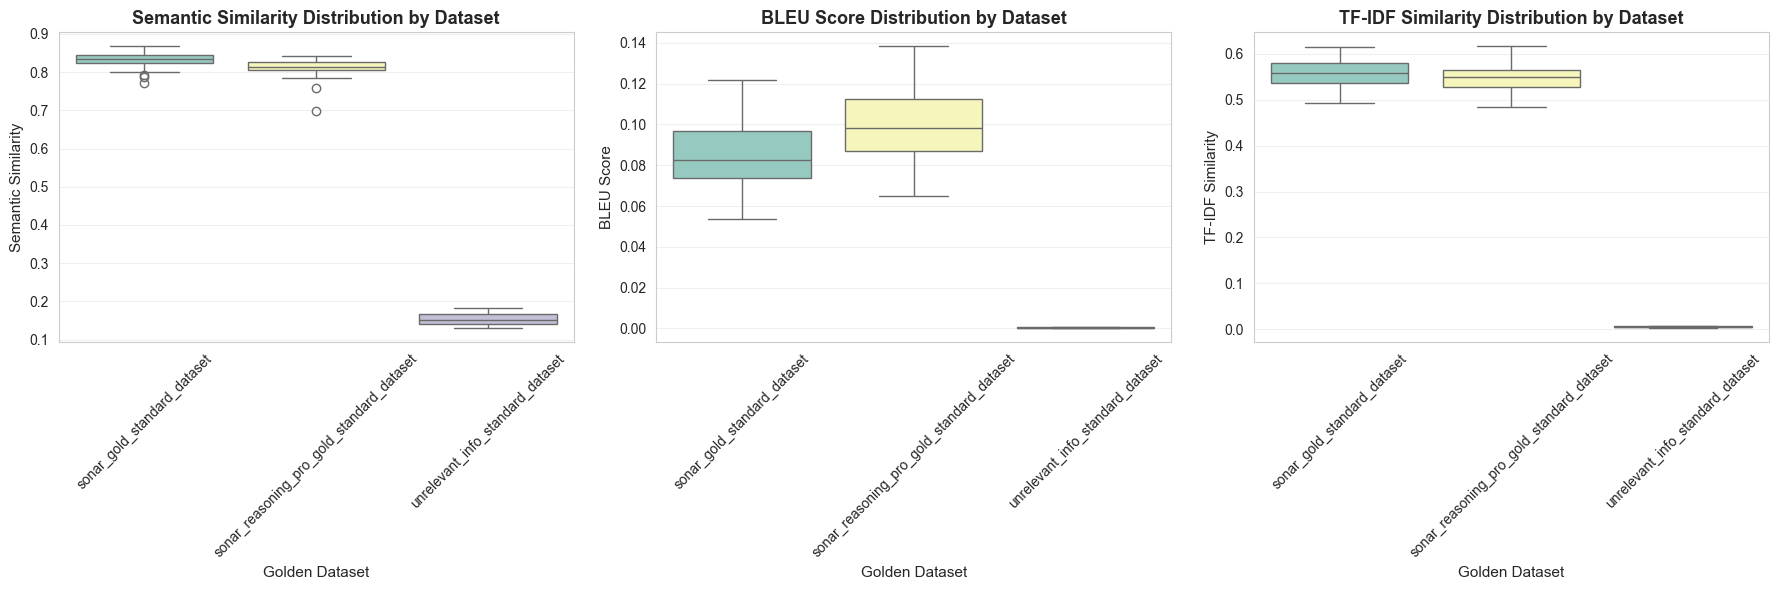

In [23]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Semantic Similarity
    sns.boxplot(data=df_latest_all, x='dataset_name', y='semantic_sim_mean', ax=axes[0], palette='Set3')
    axes[0].set_title('Semantic Similarity Distribution by Dataset', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Golden Dataset', fontsize=11)
    axes[0].set_ylabel('Semantic Similarity', fontsize=11)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # BLEU Score
    sns.boxplot(data=df_latest_all, x='dataset_name', y='bleu_mean', ax=axes[1], palette='Set3')
    axes[1].set_title('BLEU Score Distribution by Dataset', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Golden Dataset', fontsize=11)
    axes[1].set_ylabel('BLEU Score', fontsize=11)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # TF-IDF Similarity
    sns.boxplot(data=df_latest_all, x='dataset_name', y='tfidf_mean', ax=axes[2], palette='Set3')
    axes[2].set_title('TF-IDF Similarity Distribution by Dataset', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Golden Dataset', fontsize=11)
    axes[2].set_ylabel('TF-IDF Similarity', fontsize=11)
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 13.3 Model Performance Across Datasets

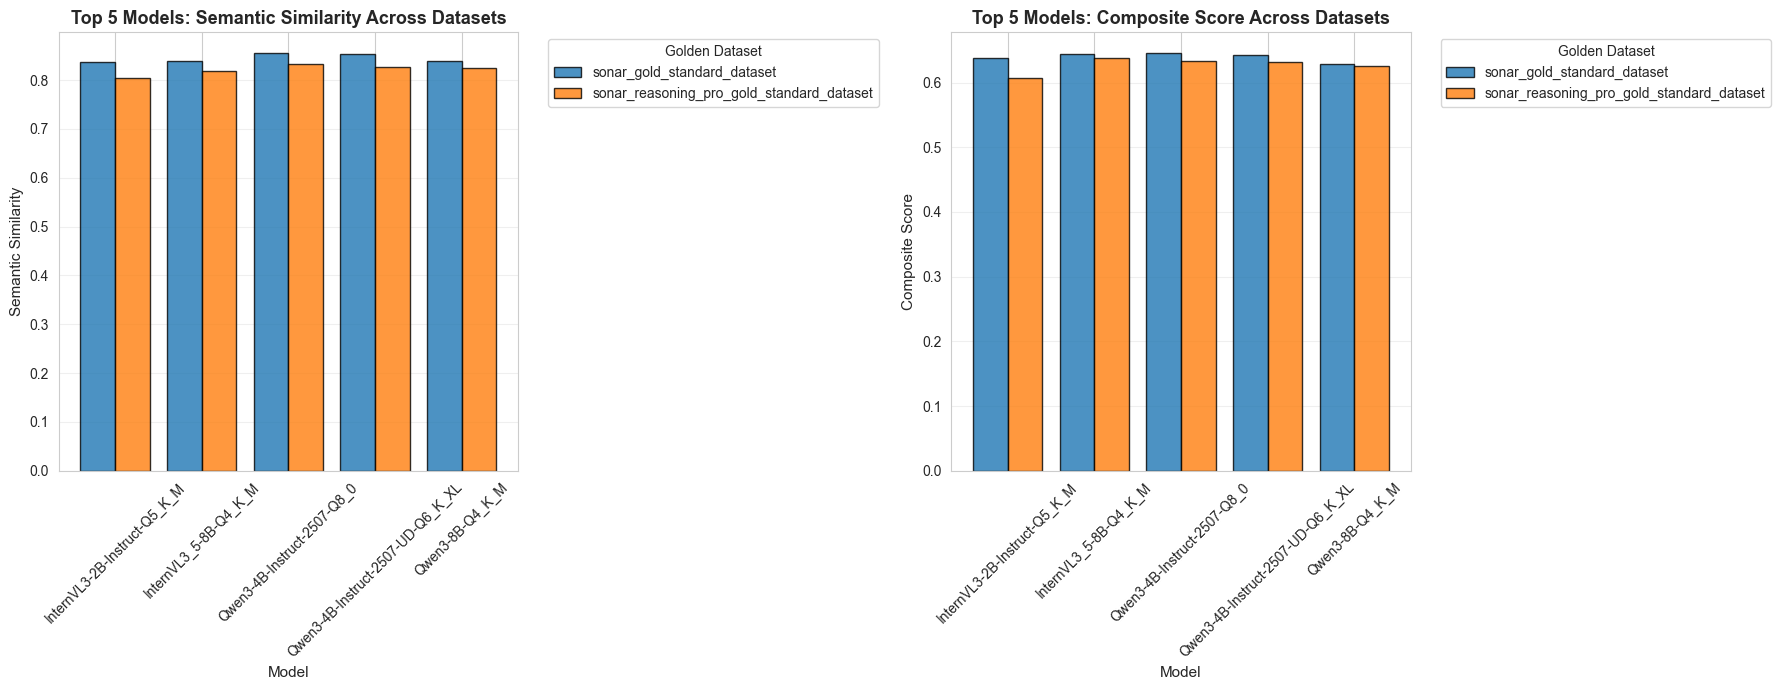

In [24]:
if len(unique_gold_datasets) > 1:
    # Get top 5 models overall
    top_models = df_latest.groupby('model')['composite_score'].mean().nlargest(5).index
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Filter data for top models
    df_top_models = df_latest[df_latest['model'].isin(top_models)]
    
    # Semantic Similarity comparison
    model_dataset_sem = df_top_models.pivot_table(
        values='semantic_sim_mean', 
        index='model', 
        columns='dataset_name', 
        aggfunc='mean'
    )
    
    model_dataset_sem.plot(kind='bar', ax=axes[0], width=0.8, edgecolor='black', alpha=0.8)
    axes[0].set_title('Top 5 Models: Semantic Similarity Across Datasets', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Semantic Similarity', fontsize=11)
    axes[0].set_xlabel('Model', fontsize=11)
    axes[0].legend(title='Golden Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Composite Score comparison
    model_dataset_comp = df_top_models.pivot_table(
        values='composite_score', 
        index='model', 
        columns='dataset_name', 
        aggfunc='mean'
    )
    
    model_dataset_comp.plot(kind='bar', ax=axes[1], width=0.8, edgecolor='black', alpha=0.8)
    axes[1].set_title('Top 5 Models: Composite Score Across Datasets', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Composite Score', fontsize=11)
    axes[1].set_xlabel('Model', fontsize=11)
    axes[1].legend(title='Golden Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 13.4 Heatmap: Dataset vs Model Performance

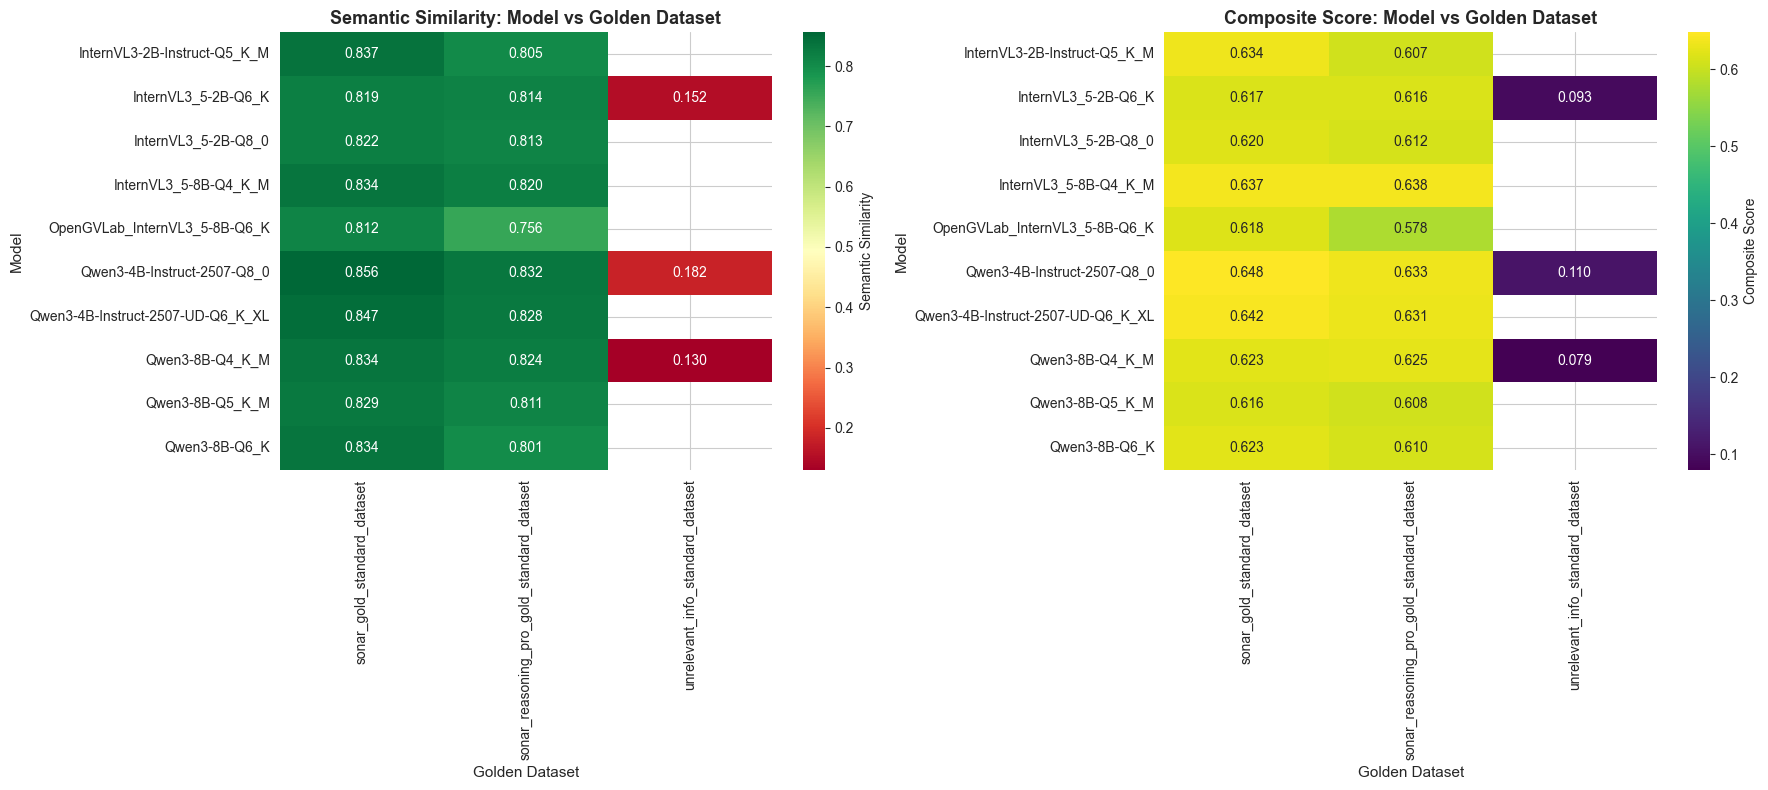

In [25]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Semantic Similarity Heatmap
    pivot_sem_dataset = df_latest_all.pivot_table(
        values='semantic_sim_mean',
        index='model',
        columns='dataset_name',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_sem_dataset, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=axes[0], cbar_kws={'label': 'Semantic Similarity'})
    axes[0].set_title('Semantic Similarity: Model vs Golden Dataset', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Golden Dataset', fontsize=11)
    axes[0].set_ylabel('Model', fontsize=11)
    
    # Composite Score Heatmap
    pivot_comp_dataset = df_latest_all.pivot_table(
        values='composite_score',
        index='model',
        columns='dataset_name',
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_comp_dataset, annot=True, fmt='.3f', cmap='viridis', 
                ax=axes[1], cbar_kws={'label': 'Composite Score'})
    axes[1].set_title('Composite Score: Model vs Golden Dataset', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Golden Dataset', fontsize=11)
    axes[1].set_ylabel('Model', fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 13.5 Top-K Impact Across Datasets

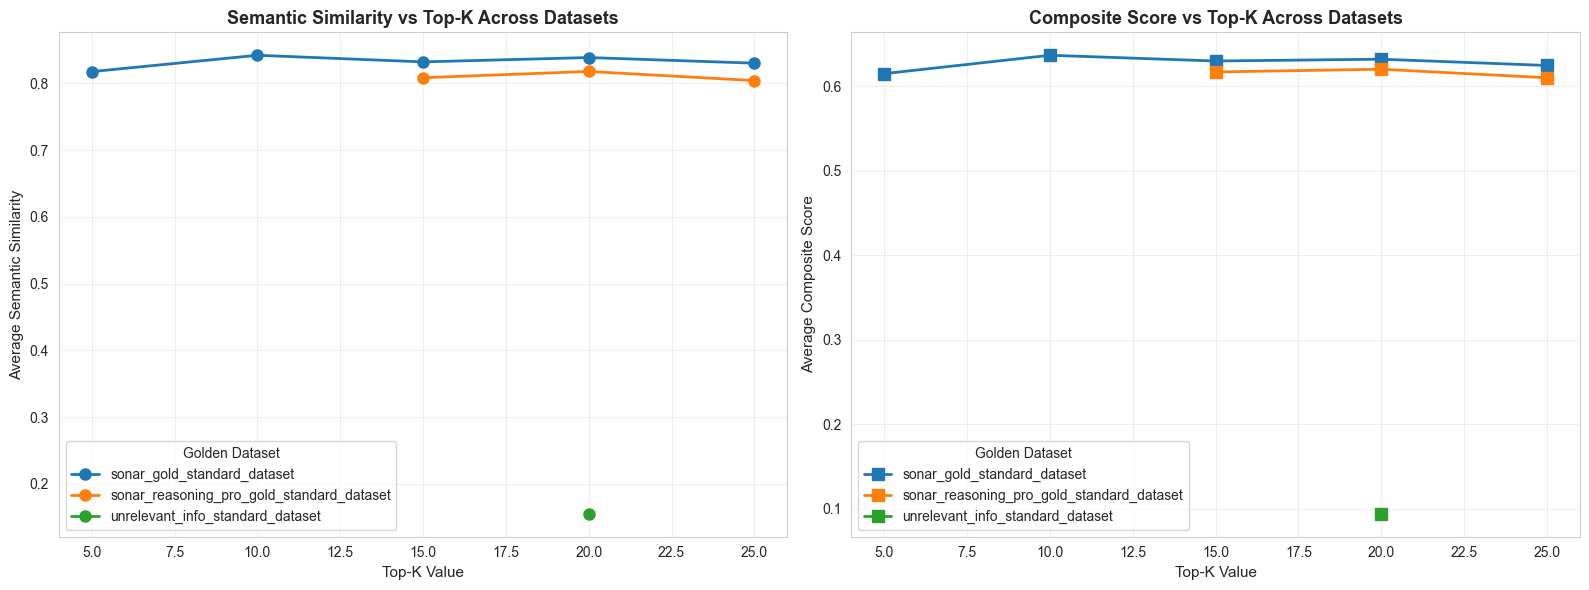

In [26]:
if len(unique_gold_datasets) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Semantic Similarity by Top-K for each dataset
    for dataset in df_latest_all['dataset_name'].unique():
        dataset_data = df_latest_all[df_latest_all['dataset_name'] == dataset]
        topk_avg = dataset_data.groupby('top_k')['semantic_sim_mean'].mean()
        axes[0].plot(topk_avg.index, topk_avg.values, marker='o', linewidth=2, 
                    label=dataset, markersize=8)
    
    axes[0].set_title('Semantic Similarity vs Top-K Across Datasets', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Top-K Value', fontsize=11)
    axes[0].set_ylabel('Average Semantic Similarity', fontsize=11)
    axes[0].legend(title='Golden Dataset', fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # Composite Score by Top-K for each dataset
    for dataset in df_latest_all['dataset_name'].unique():
        dataset_data = df_latest_all[df_latest_all['dataset_name'] == dataset]
        topk_avg = dataset_data.groupby('top_k')['composite_score'].mean()
        axes[1].plot(topk_avg.index, topk_avg.values, marker='s', linewidth=2, 
                    label=dataset, markersize=8)
    
    axes[1].set_title('Composite Score vs Top-K Across Datasets', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Top-K Value', fontsize=11)
    axes[1].set_ylabel('Average Composite Score', fontsize=11)
    axes[1].legend(title='Golden Dataset', fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

### 13.6 Variance Analysis: Dataset Consistency

VARIANCE ANALYSIS: Model Consistency Across Datasets

Lower std = More consistent across different golden datasets


semantic_sim_mean         bleu_mean          \
                                               mean     std      mean     std   
model                                                                           
InternVL3-2B-Instruct-Q5_K_M                 0.8210  0.0195    0.0886  0.0129   
InternVL3_5-2B-Q6_K                          0.8185  0.0114    0.0892  0.0135   
InternVL3_5-2B-Q8_0                          0.8169  0.0124    0.0858  0.0100   
InternVL3_5-8B-Q4_K_M                        0.8291  0.0243    0.1152  0.0164   
OpenGVLab_InternVL3_5-8B-Q6_K                0.7827  0.0527    0.0894  0.0181   
Qwen3-4B-Instruct-2507-Q8_0                  0.8438  0.0138    0.1045  0.0162   
Qwen3-4B-Instruct-2507-UD-Q6_K_XL            0.8406  0.0162    0.1013  0.0234   
Qwen3-8B-Q4_K_M                              0.8311  0.0089    0.0966  0.0143   
Qwen3-8B-Q5_K_M                              0.8224  0.0189    0.0758  0.0112   
Qwen3-8B-Q6_K                                0.8150  0.0170    0.0840  0.0161   

                                  composite_score          
                                             mean     std  
model                                                      
InternVL3-2B-Instruct-Q5_K_M               0.6225  0.0179  
InternVL3_5-2B-Q6_K                        0.6176  0.0138  
InternVL3_5-2B-Q8_0                        0.6158  0.0138  
InternVL3_5-8B-Q4_K_M                      0.6413  0.0175  
OpenGVLab_InternVL3_5-8B-Q6_K              0.5979  0.0341  
Qwen3-4B-Instruct-2507-Q8_0                0.6391  0.0079  
Qwen3-4B-Instruct-2507-UD-Q6_K_XL          0.6370  0.0114  
Qwen3-8B-Q4_K_M                            0.6269  0.0030  
Qwen3-8B-Q5_K_M                            0.6122  0.0103  
Qwen3-8B-Q6_K                              0.6141  0.0105

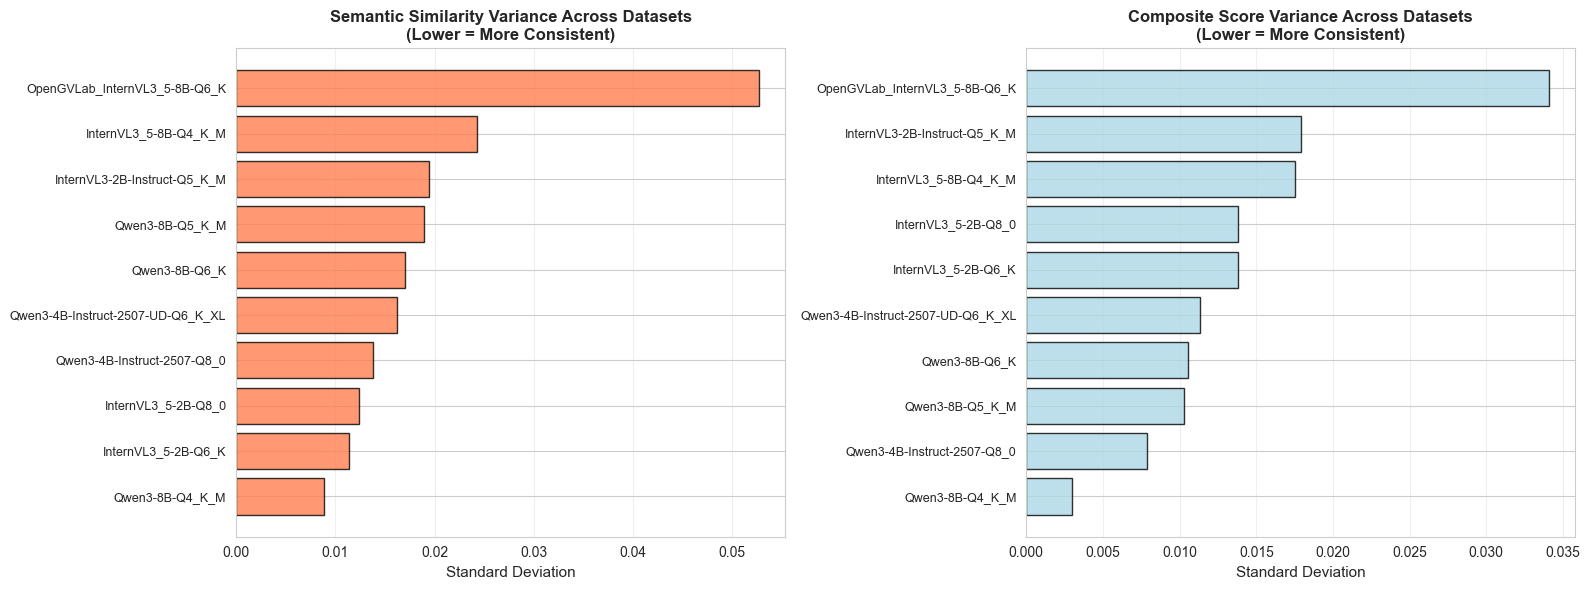

In [27]:
if len(unique_gold_datasets) > 1:
    # Calculate standard deviation across datasets for each model
    variance_analysis = df_latest.groupby('model').agg({
        'semantic_sim_mean': ['mean', 'std'],
        'bleu_mean': ['mean', 'std'],
        'composite_score': ['mean', 'std']
    }).round(4)
    
    print("="*80)
    print("VARIANCE ANALYSIS: Model Consistency Across Datasets")
    print("="*80)
    print("\nLower std = More consistent across different golden datasets")
    display(variance_analysis)
    
    # Visualize variance
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    std_data = df_latest.groupby('model')['semantic_sim_mean'].std().sort_values()
    axes[0].barh(range(len(std_data)), std_data.values, color='coral', edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(len(std_data)))
    axes[0].set_yticklabels(std_data.index, fontsize=9)
    axes[0].set_xlabel('Standard Deviation', fontsize=11)
    axes[0].set_title('Semantic Similarity Variance Across Datasets\n(Lower = More Consistent)', 
                     fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3, axis='x')
    
    std_comp = df_latest.groupby('model')['composite_score'].std().sort_values()
    axes[1].barh(range(len(std_comp)), std_comp.values, color='lightblue', edgecolor='black', alpha=0.8)
    axes[1].set_yticks(range(len(std_comp)))
    axes[1].set_yticklabels(std_comp.index, fontsize=9)
    axes[1].set_xlabel('Standard Deviation', fontsize=11)
    axes[1].set_title('Composite Score Variance Across Datasets\n(Lower = More Consistent)', 
                     fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
else:
    print("Skipping: Only one golden dataset available.")

## 14. Dataset Comparison Summary

Generate final summary comparing all golden datasets.

In [28]:
if len(unique_gold_datasets) > 1:
    print("="*80)
    print("GOLDEN DATASET COMPARISON SUMMARY")
    print("="*80)
    
    for dataset in df_latest['dataset_name'].unique():
        dataset_df = df_latest[df_latest['dataset_name'] == dataset]
        
        print(f"\n{'='*80}")
        print(f"📊 Dataset: {dataset}")
        print(f"{'='*80}")
        
        print(f"\n📈 Statistics:")
        print(f"   • Number of configurations: {len(dataset_df)}")
        print(f"   • Avg Semantic Similarity: {dataset_df['semantic_sim_mean'].mean():.4f}")
        print(f"   • Avg BLEU Score: {dataset_df['bleu_mean'].mean():.4f}")
        print(f"   • Avg TF-IDF Similarity: {dataset_df['tfidf_mean'].mean():.4f}")
        print(f"   • Avg Response Time: {dataset_df['response_time_mean'].mean():.2f}s")
        print(f"   • Avg Composite Score: {dataset_df['composite_score'].mean():.4f}")
        
        # Best model for this dataset
        best = dataset_df.nlargest(1, 'composite_score').iloc[0]
        print(f"\n🏆 Best Configuration:")
        print(f"   • Model: {best['model']}")
        print(f"   • Top-K: {best['top_k']}")
        print(f"   • Composite Score: {best['composite_score']:.4f}")
        
        # Metric ranges
        print(f"\n📊 Metric Ranges:")
        print(f"   • Semantic Similarity: {dataset_df['semantic_sim_mean'].min():.4f} - {dataset_df['semantic_sim_mean'].max():.4f}")
        print(f"   • BLEU Score: {dataset_df['bleu_mean'].min():.4f} - {dataset_df['bleu_mean'].max():.4f}")
        print(f"   • Response Time: {dataset_df['response_time_mean'].min():.2f}s - {dataset_df['response_time_mean'].max():.2f}s")
    
    # Overall comparison
    print("\n" + "="*80)
    print("🎯 DATASET RANKING BY AVERAGE COMPOSITE SCORE")
    print("="*80)
    
    dataset_ranking = df_latest.groupby('dataset_name')['composite_score'].mean().sort_values(ascending=False)
    for rank, (dataset, score) in enumerate(dataset_ranking.items(), 1):
        print(f"{rank}. {dataset}: {score:.4f}")
    
    print("\n" + "="*80)
    print("✅ DATASET COMPARISON COMPLETE")
    print("="*80)
    
else:
    print("="*80)
    print("Only one golden dataset found.")
    print(f"Dataset: {df_latest['dataset_name'].iloc[0]}")
    print("No comparison analysis needed.")
    print("="*80)

GOLDEN DATASET COMPARISON SUMMARY

📊 Dataset: sonar_gold_standard_dataset

📈 Statistics:
   • Number of configurations: 30
   • Avg Semantic Similarity: 0.8339
   • Avg BLEU Score: 0.0857
   • Avg TF-IDF Similarity: 0.5576
   • Avg Response Time: 21.08s
   • Avg Composite Score: 0.6290

🏆 Best Configuration:
   • Model: Qwen3-4B-Instruct-2507-UD-Q6_K_XL
   • Top-K: 15
   • Composite Score: 0.6594

📊 Metric Ranges:
   • Semantic Similarity: 0.7726 - 0.8673
   • BLEU Score: 0.0613 - 0.1133
   • Response Time: 2.50s - 48.17s

📊 Dataset: sonar_reasoning_pro_gold_standard_dataset

📈 Statistics:
   • Number of configurations: 30
   • Avg Semantic Similarity: 0.8103
   • Avg BLEU Score: 0.1004
   • Avg TF-IDF Similarity: 0.5479
   • Avg Response Time: 18.91s
   • Avg Composite Score: 0.6159

🏆 Best Configuration:
   • Model: InternVL3_5-8B-Q4_K_M
   • Top-K: 20
   • Composite Score: 0.6528

📊 Metric Ranges:
   • Semantic Similarity: 0.6984 - 0.8411
   • BLEU Score: 0.0649 - 0.1382
   • Respon

## 15. Export Golden Dataset Comparison Results

Save comparison results for the different golden datasets.

In [29]:
if len(unique_gold_datasets) > 1:
    # Export dataset comparison summary
    dataset_summary = df_latest.groupby('dataset_name').agg({
        'semantic_sim_mean': ['mean', 'std', 'min', 'max', 'count'],
        'bleu_mean': ['mean', 'std', 'min', 'max'],
        'tfidf_mean': ['mean', 'std', 'min', 'max'],
        'response_time_mean': ['mean', 'std', 'min', 'max'],
        'composite_score': ['mean', 'std', 'min', 'max']
    }).round(4)
    
    dataset_summary.to_csv('golden_dataset_comparison.csv')
    print("✓ Golden dataset comparison saved to: golden_dataset_comparison.csv")
    
    # Export best config per dataset
    best_per_dataset = []
    for dataset in df_latest['dataset_name'].unique():
        dataset_df = df_latest[df_latest['dataset_name'] == dataset]
        best = dataset_df.nlargest(1, 'composite_score').iloc[0]
        best_per_dataset.append({
            'dataset': dataset,
            'best_model': best['model'],
            'best_top_k': best['top_k'],
            'semantic_sim': best['semantic_sim_mean'],
            'bleu_score': best['bleu_mean'],
            'tfidf_sim': best['tfidf_mean'],
            'response_time': best['response_time_mean'],
            'composite_score': best['composite_score']
        })
    
    pd.DataFrame(best_per_dataset).to_csv('best_config_per_dataset.csv', index=False)
    print("✓ Best configuration per dataset saved to: best_config_per_dataset.csv")
    
    # Export detailed comparison
    df_latest[['dataset_name', 'model', 'top_k', 'semantic_sim_mean', 'bleu_mean', 
               'tfidf_mean', 'response_time_mean', 'composite_score']].to_csv(
        'detailed_dataset_comparison.csv', index=False
    )
    print("✓ Detailed dataset comparison saved to: detailed_dataset_comparison.csv")
    
    print("\n" + "="*80)
    print("All dataset comparison results exported successfully!")
    print("="*80)
else:
    print("Only one golden dataset - no comparison export needed.")

✓ Golden dataset comparison saved to: golden_dataset_comparison.csv
✓ Best configuration per dataset saved to: best_config_per_dataset.csv
✓ Detailed dataset comparison saved to: detailed_dataset_comparison.csv

All dataset comparison results exported successfully!
